In [ ]:
import os
import re
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
from transformers import AutoTokenizer
import tqdm


In [ ]:
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 12

In [ ]:
model_path = "GSAI-ML/LLaDA-8B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(model_path, trust_remote_code=True)

In [4]:
def normalize_number(num_str: str) -> str:
    """Normalize number format: 12.00 -> 12, remove commas, dollar signs"""
    if not num_str:
        return ""
    # Remove dollar signs, commas, and extra spaces
    cleaned = num_str.replace("$", "").replace(",", "").strip()
    try:
        # Try to parse as float first
        num = float(cleaned)
        # If it's a whole number, return as int string
        if num.is_integer():
            return str(int(num))
        else:
            # Remove trailing zeros for decimals
            return str(num).rstrip('0').rstrip('.')
    except (ValueError, TypeError):
        # If not a valid number, return cleaned string
        return cleaned

def extract_answer_from_prediction(pred: str) -> str:
    """Extract the number after "Answer:" (case-insensitive); fallback to last number."""
    m = re.search(r"Answer:([^\d-]*)?(-?\d+[\d,\.]*)", pred, re.IGNORECASE)
    if m:
        return normalize_number(m.group(2))

    numbers = re.findall(r"-?\d+(?:\.\d+)?", pred)
    return normalize_number(numbers[-1]) if numbers else ""

def find_subsequence_index(haystack, needle):
    """Find the last starting index of needle subsequence in haystack list."""
    if not needle:
        return -1
    
    last_index = -1
    all_occur_lst = []
    for i in range(len(haystack) - len(needle) + 1):
        if haystack[i:i + len(needle)] == needle:
            last_index = i
            all_occur_lst.append(i)
    
    return last_index, all_occur_lst

In [5]:
GSM8K_COUNT=1319

In [6]:
correct_early_results = []
correct_early_results_dict = []
correct_count = 0
for q_i in range(GSM8K_COUNT):
    path = f'./question_histories_low_conf_none_index_genlen_step256_blocklen32/question_{q_i:04}_steps_256.pt'
    question_dict = torch.load(path)
    x0_history_blocks = question_dict['x0_history']
    all_steps = torch.cat(x0_history_blocks, dim=0) 
    
    extracted_ans = extract_answer_from_prediction(question_dict['pred_text'])
    
    if_correct = extracted_ans == normalize_number(question_dict['gt_text'])
    if if_correct:
        correct_count += 1
        
        last_index = question_dict['ans_posidx']
        pred_ans_len = len(question_dict['pred_token_id'])
        pred_token_id = question_dict['pred_token_id']
        appear_time_steps = []
        for s_i in range(all_steps.shape[0] - 1):
            cand_ans_pos_tokens = all_steps[s_i, last_index:last_index + pred_ans_len].tolist()
            if cand_ans_pos_tokens == pred_token_id:
                appear_time_steps.append(s_i)
                
        appear_time_steps.append(all_steps.shape[0] - 1)
        
        if len(appear_time_steps) > 0:
            early_results = appear_time_steps[-1] - appear_time_steps[0]
            correct_early_results.append(early_results)
            correct_early_results_dict.append((q_i, appear_time_steps))
        else:
            print(last_index, pred_ans_len, question_dict['ans_posidx'])

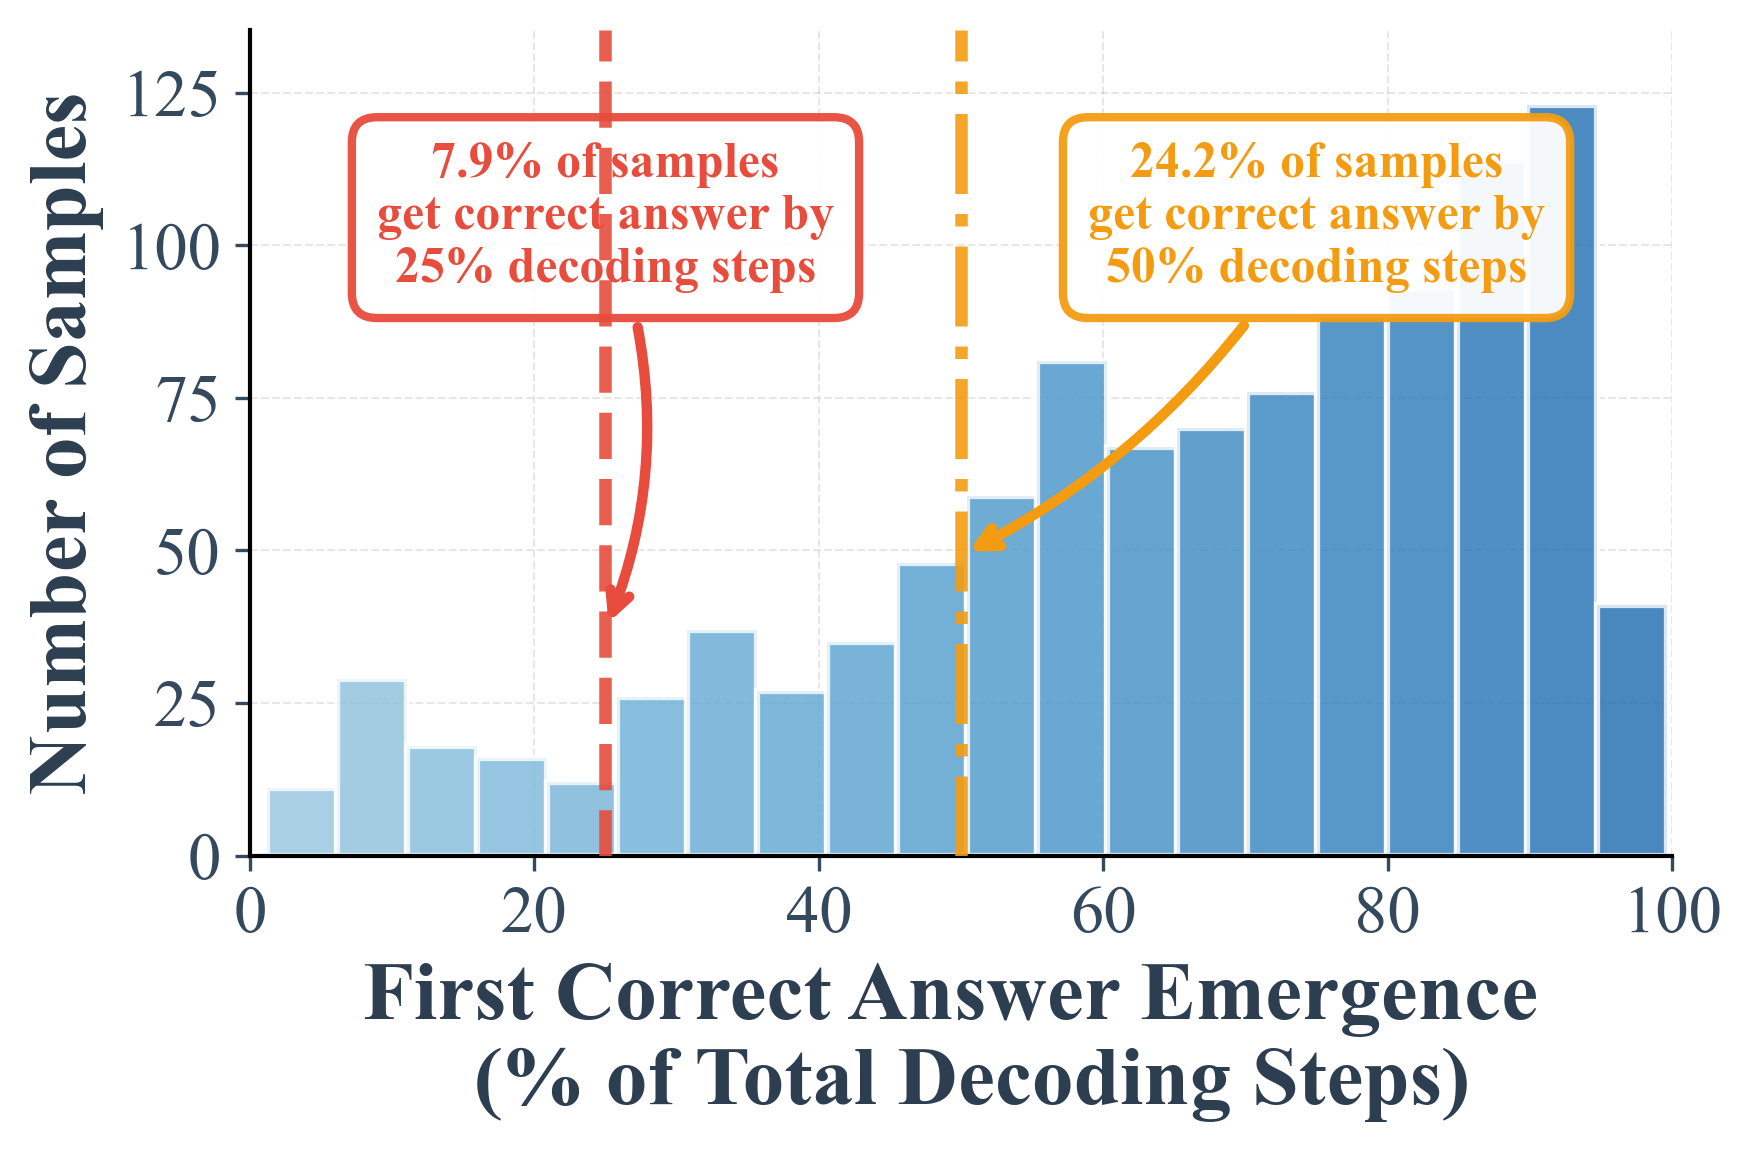

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

total_timestep = 256

# Create the figure with better proportions
fig, ax = plt.subplots(figsize=(6, 4), dpi=300)

# Create histogram with improved styling and more fine-grained bins
n, bins, patches = ax.hist(
    [(item[1][0] / total_timestep) * 100 for item in correct_early_results_dict], 
    bins=20,  # Increased from 10 to 20 for more fine-grained bins
    edgecolor='white', 
    linewidth=1.5,
    alpha=0.8,
    color='#4A90E2',  # Professional blue
    density=False
)

# Enhance the bars with gradient effect
for i, patch in enumerate(patches):
    patch.set_facecolor(plt.cm.Blues(0.4 + 0.4 * (i / len(patches))))

# Calculate cumulative statistics
correct_early_results_pct = [(item[1][0] / total_timestep) * 100 for item in correct_early_results_dict]
sorted_pct = np.sort(correct_early_results_pct)
total_samples = len(correct_early_results_pct)

# Fix specific decoding step thresholds and calculate what % of samples achieve correct answers by then
threshold_1 = 25.0  # 25% of decoding steps
threshold_2 = 50.0  # 50% of decoding steps

# Calculate percentage of samples that achieve correct answers by each threshold
samples_by_1 = np.sum(np.array(correct_early_results_pct) <= threshold_1) / total_samples * 100
samples_by_2 = np.sum(np.array(correct_early_results_pct) <= threshold_2) / total_samples * 100

# Add vertical lines for fixed thresholds
ax.axvline(threshold_1, color='#E74C3C', linestyle='--', linewidth=3, 
           alpha=0.9, zorder=5)
ax.axvline(threshold_2, color='#F39C12', linestyle='-.', linewidth=3, 
           alpha=0.9, zorder=5)

# Add annotation for 50% threshold
ax.annotate(f'{samples_by_1:.1f}% of samples\nget correct answer by\n{threshold_1:.0f}% decoding steps', 
            xy=(threshold_1, max(n)*0.3), 
            xytext=(25, max(n)*0.85),  # Position in upper left white area
            arrowprops=dict(arrowstyle='->', color='#E74C3C', lw=2.5, 
                          connectionstyle="arc3,rad=-0.2"),
            fontsize=12, fontweight='bold', color='#E74C3C',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', 
                     edgecolor='#E74C3C', linewidth=2, alpha=0.95),
            ha='center', va='center')

# Add annotation for 70% threshold
ax.annotate(f'{samples_by_2:.1f}% of samples\nget correct answer by\n{threshold_2:.0f}% decoding steps', 
            xy=(threshold_2, max(n)*0.4), 
            xytext=(75, max(n)*0.85),  # Position below the first annotation
            arrowprops=dict(arrowstyle='->', color='#F39C12', lw=2.5, 
                          connectionstyle="arc3,rad=-0.15"),
            fontsize=12, fontweight='bold', color='#F39C12',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', 
                     edgecolor='#F39C12', linewidth=2, alpha=0.95),
            ha='center', va='center')

# Enhanced labels and title
ax.set_xlabel('First Correct Answer Emergence \n (% of Total Decoding Steps)', 
              fontsize=20, fontweight='bold', color='#2C3E50')
ax.set_ylabel('Number of Samples', 
              fontsize=20, fontweight='bold', color='#2C3E50')

# Improve tick styling
ax.tick_params(axis='both', which='major', labelsize=16, colors='#34495E')

ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax.set_axisbelow(True)

ax.set_xlim(0, 100)
ax.set_ylim(0, max(n) * 1.1)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1)
ax.spines['bottom'].set_linewidth(1)

# Adjust layout
plt.tight_layout()

# plt.savefig('figures/paper/early_correct_detection_distribution_low_conf_non.pdf', 
#             dpi=300, bbox_inches='tight', facecolor='white')

plt.show()

In [8]:
correct_early_results_suffix = []
correct_early_results_dict_suffix = []
correct_count = 0
for q_i in range(GSM8K_COUNT):
    path = f'./question_histories_low_conf_constraint_index_genlen_step256_blocklen32/question_{q_i:04}_steps_256.pt'
    question_dict = torch.load(path)

    x0_history_blocks = question_dict['x0_history']
    all_steps = torch.cat(x0_history_blocks, dim=0) 
    
    extracted_ans = extract_answer_from_prediction(question_dict['pred_text'])
    
    if_correct = extracted_ans == normalize_number(question_dict['gt_text'])
    if if_correct:
        correct_count += 1
        
        last_index = question_dict['ans_posidx']
        pred_ans_len = len(question_dict['pred_token_id'])
        pred_token_id = question_dict['pred_token_id']
        appear_time_steps = []
        for s_i in range(all_steps.shape[0] - 1):
            cand_ans_pos_tokens = all_steps[s_i, last_index:last_index + pred_ans_len].tolist()
            if cand_ans_pos_tokens == pred_token_id:
                appear_time_steps.append(s_i)
                
        appear_time_steps.append(all_steps.shape[0] - 1)
        
        if len(appear_time_steps) > 0:
            early_results = appear_time_steps[-1] - appear_time_steps[0]
            correct_early_results_suffix.append(early_results)
            correct_early_results_dict_suffix.append((q_i, appear_time_steps))
        else:
            print(last_index, pred_ans_len, question_dict['ans_posidx'])

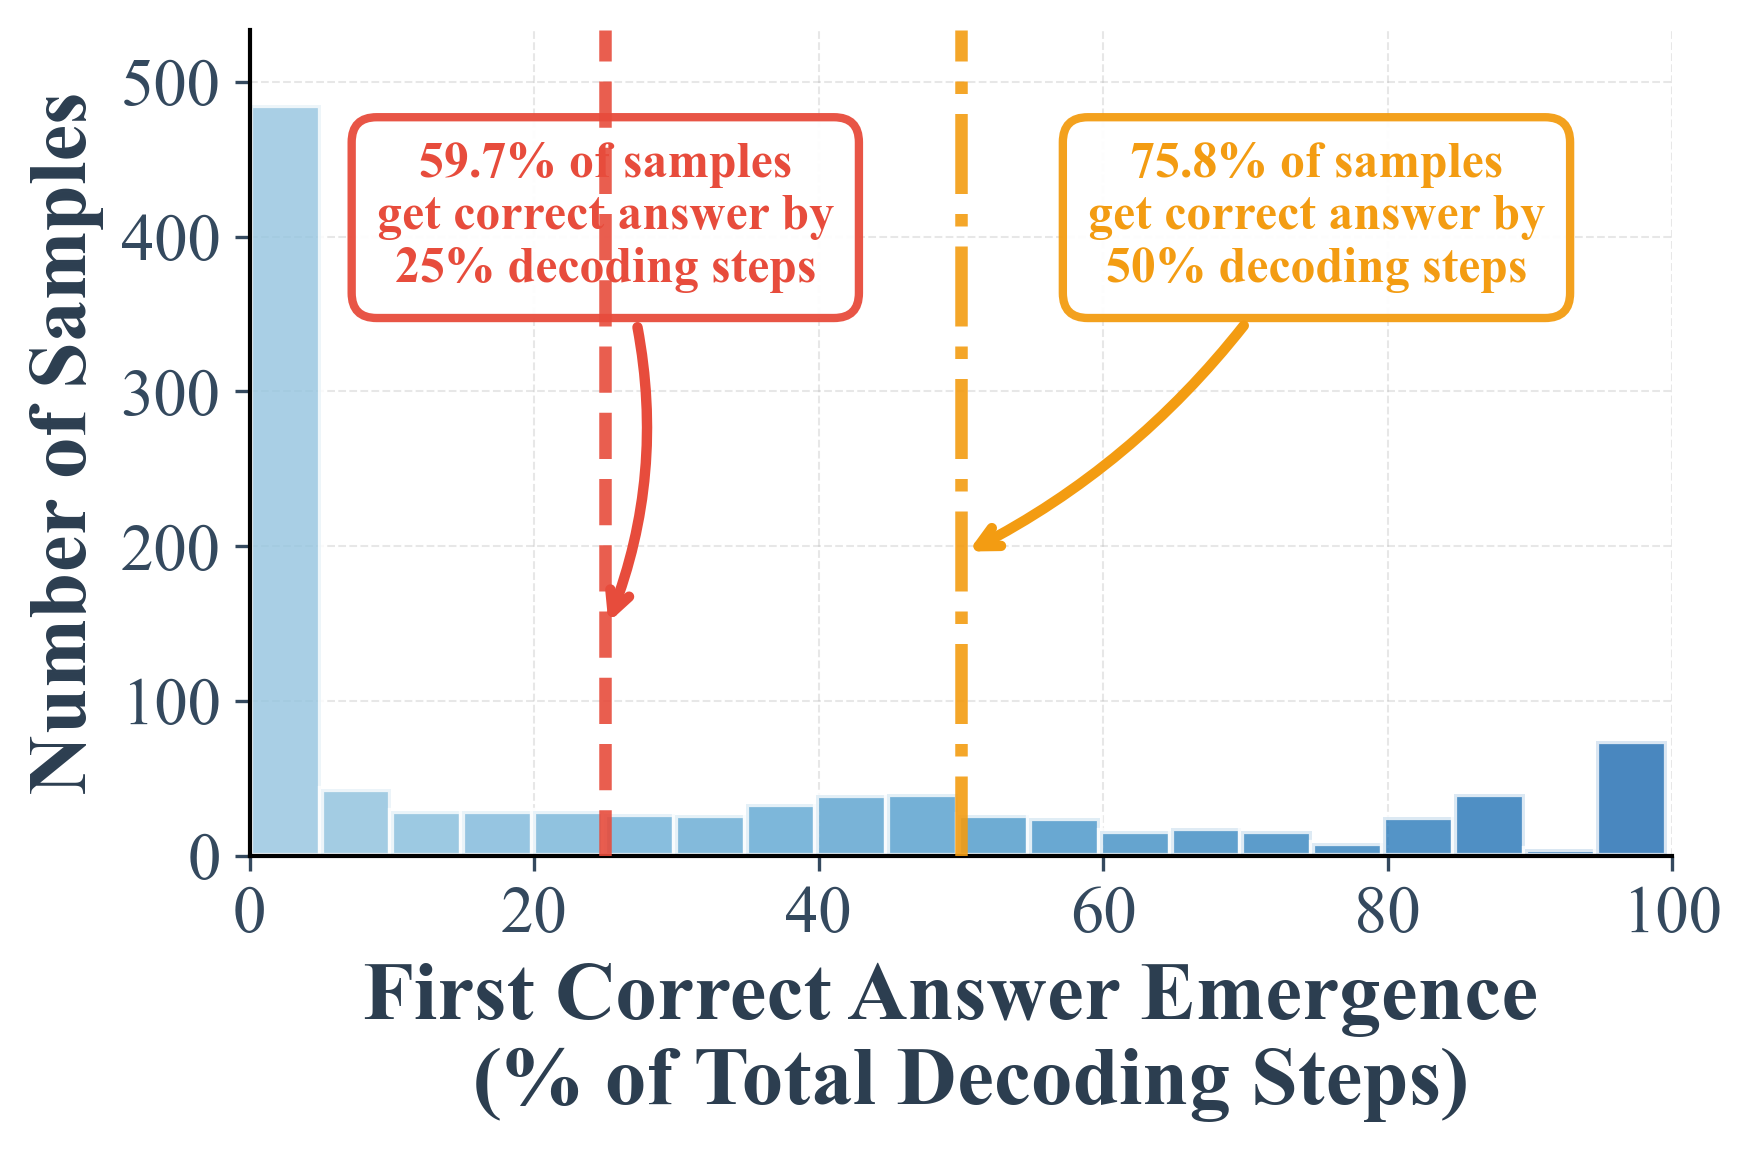

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

total_timestep = 256

# Create the figure with better proportions
fig, ax = plt.subplots(figsize=(6, 4), dpi=300)

# Create histogram with improved styling and more fine-grained bins
n, bins, patches = ax.hist(
    [(item[1][0] / total_timestep) * 100 for item in correct_early_results_dict_suffix], 
    bins=20,  # Increased from 10 to 20 for more fine-grained bins
    edgecolor='white', 
    linewidth=1.5,
    alpha=0.8,
    color='#4A90E2',  # Professional blue
    density=False
)

# Enhance the bars with gradient effect
for i, patch in enumerate(patches):
    patch.set_facecolor(plt.cm.Blues(0.4 + 0.4 * (i / len(patches))))

# Calculate cumulative statistics
correct_early_results_pct = [(item[1][0] / total_timestep) * 100 for item in correct_early_results_dict_suffix]
sorted_pct = np.sort(correct_early_results_pct)
total_samples = len(correct_early_results_pct)

# Fix specific decoding step thresholds and calculate what % of samples achieve correct answers by then
threshold_1 = 25.0  # 25% of decoding steps
threshold_2 = 50.0  # 25% of decoding steps

# Calculate percentage of samples that achieve correct answers by each threshold
samples_by_1 = np.sum(np.array(correct_early_results_pct) <= threshold_1) / total_samples * 100
samples_by_2 = np.sum(np.array(correct_early_results_pct) <= threshold_2) / total_samples * 100

# Add vertical lines for fixed thresholds
ax.axvline(threshold_1, color='#E74C3C', linestyle='--', linewidth=3, 
           alpha=0.9, zorder=5)
ax.axvline(threshold_2, color='#F39C12', linestyle='-.', linewidth=3, 
           alpha=0.9, zorder=5)

# Add annotation for 50% threshold
ax.annotate(f'{samples_by_1:.1f}% of samples\nget correct answer by\n{threshold_1:.0f}% decoding steps', 
            xy=(threshold_1, max(n)*0.3), 
            xytext=(25, max(n)*0.85),  # Position in upper left white area
            arrowprops=dict(arrowstyle='->', color='#E74C3C', lw=2.5, 
                          connectionstyle="arc3,rad=-0.2"),
            fontsize=12, fontweight='bold', color='#E74C3C',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', 
                     edgecolor='#E74C3C', linewidth=2, alpha=0.95),
            ha='center', va='center')

# Add annotation for 70% threshold
ax.annotate(f'{samples_by_2:.1f}% of samples\nget correct answer by\n{threshold_2:.0f}% decoding steps', 
            xy=(threshold_2, max(n)*0.4), 
            xytext=(75, max(n)*0.85),  # Position below the first annotation
            arrowprops=dict(arrowstyle='->', color='#F39C12', lw=2.5, 
                          connectionstyle="arc3,rad=-0.15"),
            fontsize=12, fontweight='bold', color='#F39C12',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', 
                     edgecolor='#F39C12', linewidth=2, alpha=0.95),
            ha='center', va='center')

# Enhanced labels and title
ax.set_xlabel('First Correct Answer Emergence \n (% of Total Decoding Steps)', 
              fontsize=20, fontweight='bold', color='#2C3E50')
ax.set_ylabel('Number of Samples', 
              fontsize=20, fontweight='bold', color='#2C3E50')

# Improve tick styling
ax.tick_params(axis='both', which='major', labelsize=16, colors='#34495E')

ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax.set_axisbelow(True)

ax.set_xlim(0, 100)
ax.set_ylim(0, max(n) * 1.1)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1)
ax.spines['bottom'].set_linewidth(1)

# Adjust layout
plt.tight_layout()

# plt.savefig('figures/paper/early_correct_detection_distribution_low_conf_constraint_suffix.pdf', 
#             dpi=300, bbox_inches='tight', facecolor='white')

plt.show()

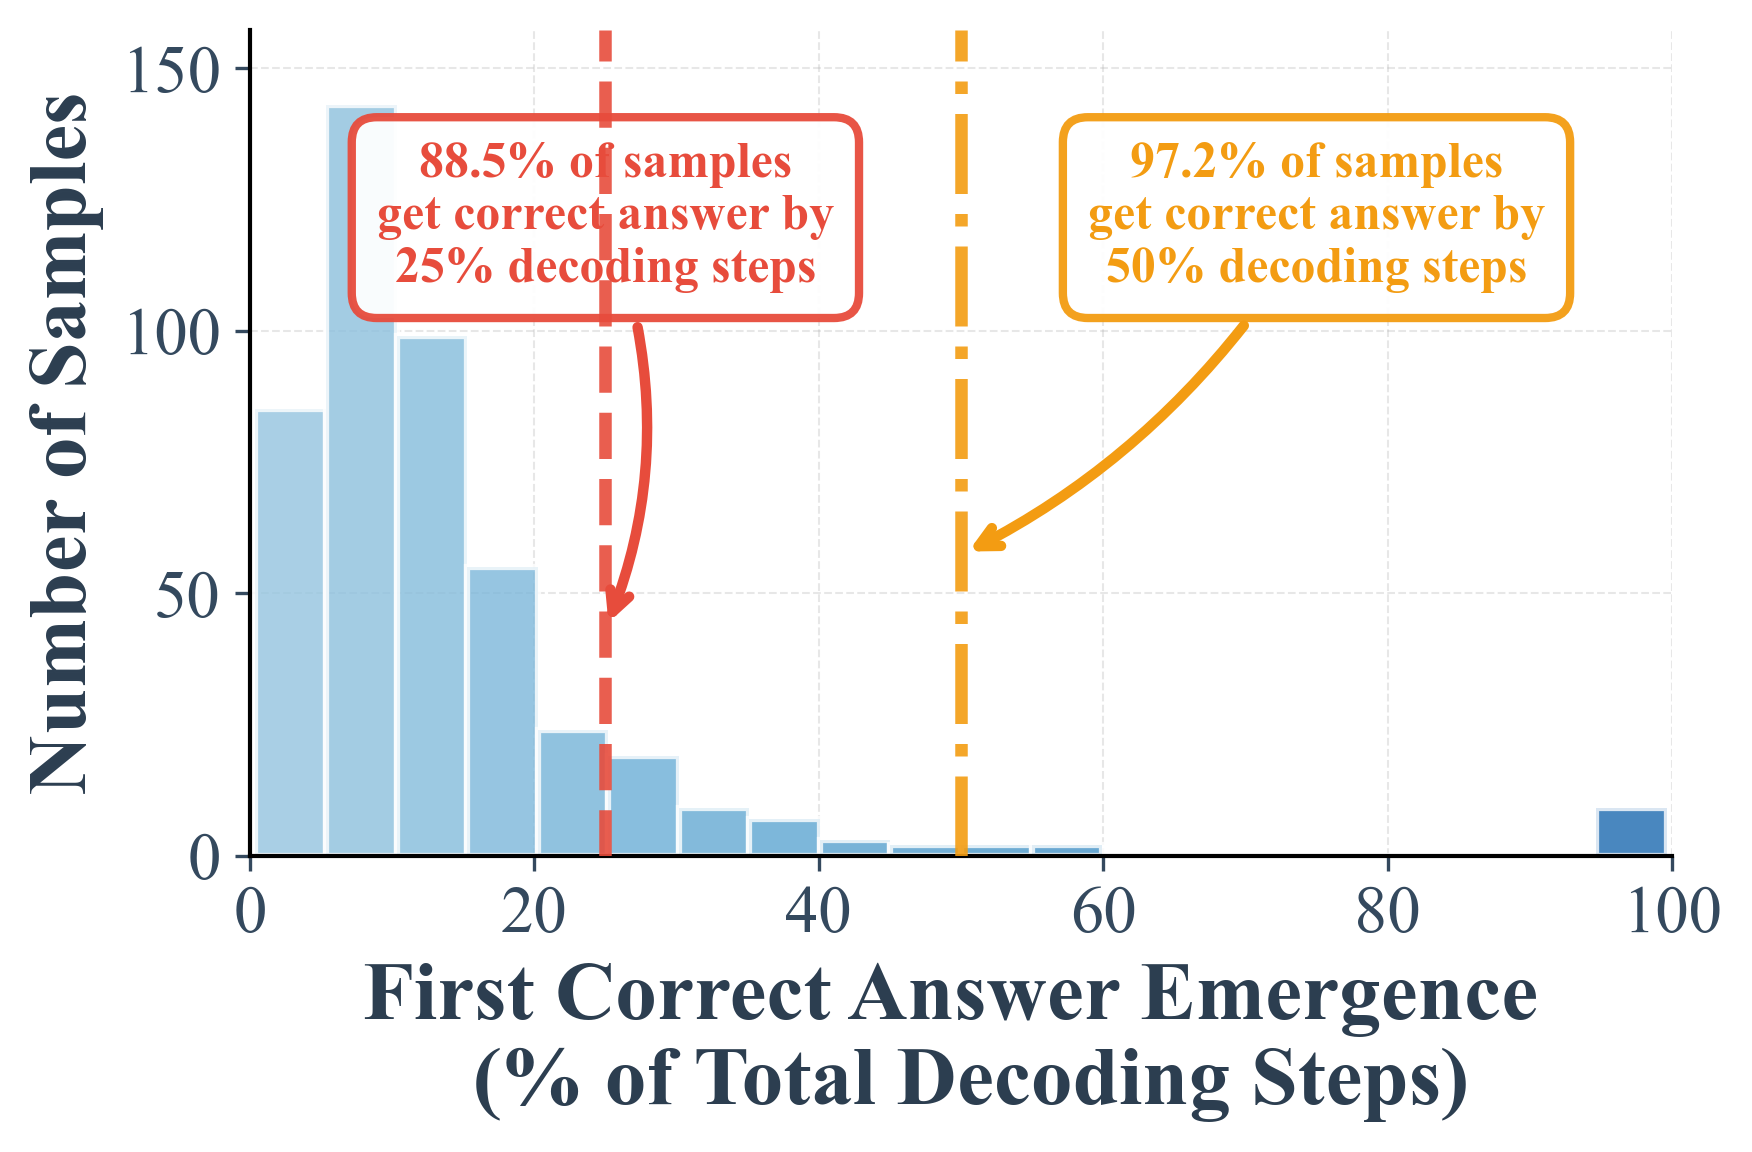

In [ ]:
GSM8K_COUNT=1319
correct_early_results_random = []
correct_early_results_dict_random = []
correct_count = 0
for q_i in range(GSM8K_COUNT):
    path = f'./question_histories_random_none_index_genlen_step256_blocklen256/question_{q_i:04}_steps_256.pt'
    question_dict = torch.load(path)
    x0_history_blocks = question_dict['x0_history']
    all_steps = torch.cat(x0_history_blocks, dim=0) 
    
    extracted_ans = extract_answer_from_prediction(question_dict['pred_text'])
    
    if_correct = extracted_ans == normalize_number(question_dict['gt_text'])
    if if_correct:
        correct_count += 1
        
        last_index = question_dict['ans_posidx']
        pred_ans_len = len(question_dict['pred_token_id'])
        pred_token_id = question_dict['pred_token_id']
        appear_time_steps = []
        for s_i in range(all_steps.shape[0] - 1):
            cand_ans_pos_tokens = all_steps[s_i, last_index:last_index + pred_ans_len].tolist()
            if cand_ans_pos_tokens == pred_token_id:
                appear_time_steps.append(s_i)
                
        appear_time_steps.append(all_steps.shape[0] - 1)
        
        if len(appear_time_steps) > 0:
            early_results = appear_time_steps[-1] - appear_time_steps[0]
            correct_early_results_random.append(early_results)
            correct_early_results_dict_random.append((q_i, appear_time_steps))
        else:
            print(last_index, pred_ans_len, question_dict['ans_posidx'])
            

total_timestep = 256

# Create the figure with better proportions
fig, ax = plt.subplots(figsize=(6, 4), dpi=300)

# Create histogram with improved styling and more fine-grained bins
n, bins, patches = ax.hist(
    [(item[1][0] / total_timestep) * 100 for item in correct_early_results_dict_random], 
    bins=20,  # Increased from 10 to 20 for more fine-grained bins
    edgecolor='white', 
    linewidth=1.5,
    alpha=0.8,
    color='#4A90E2',  # Professional blue
    density=False
)

# Enhance the bars with gradient effect
for i, patch in enumerate(patches):
    patch.set_facecolor(plt.cm.Blues(0.4 + 0.4 * (i / len(patches))))

# Calculate cumulative statistics
correct_early_results_pct = [(item[1][0] / total_timestep) * 100 for item in correct_early_results_dict_random]
sorted_pct = np.sort(correct_early_results_pct)
total_samples = len(correct_early_results_pct)

# Fix specific decoding step thresholds and calculate what % of samples achieve correct answers by then
threshold_1 = 25.0  # 25% of decoding steps
threshold_2 = 50.0  # 50% of decoding steps

# Calculate percentage of samples that achieve correct answers by each threshold
samples_by_1 = np.sum(np.array(correct_early_results_pct) <= threshold_1) / total_samples * 100
samples_by_2 = np.sum(np.array(correct_early_results_pct) <= threshold_2) / total_samples * 100

# Add vertical lines for fixed thresholds
ax.axvline(threshold_1, color='#E74C3C', linestyle='--', linewidth=3, 
           alpha=0.9, zorder=5)
ax.axvline(threshold_2, color='#F39C12', linestyle='-.', linewidth=3, 
           alpha=0.9, zorder=5)

# Add annotation for 50% threshold
ax.annotate(f'{samples_by_1:.1f}% of samples\nget correct answer by\n{threshold_1:.0f}% decoding steps', 
            xy=(threshold_1, max(n)*0.3), 
            xytext=(25, max(n)*0.85),  # Position in upper left white area
            arrowprops=dict(arrowstyle='->', color='#E74C3C', lw=2.5, 
                          connectionstyle="arc3,rad=-0.2"),
            fontsize=12, fontweight='bold', color='#E74C3C',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', 
                     edgecolor='#E74C3C', linewidth=2, alpha=0.95),
            ha='center', va='center')

# Add annotation for 70% threshold
ax.annotate(f'{samples_by_2:.1f}% of samples\nget correct answer by\n{threshold_2:.0f}% decoding steps', 
            xy=(threshold_2, max(n)*0.4), 
            xytext=(75, max(n)*0.85),  # Position below the first annotation
            arrowprops=dict(arrowstyle='->', color='#F39C12', lw=2.5, 
                          connectionstyle="arc3,rad=-0.15"),
            fontsize=12, fontweight='bold', color='#F39C12',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', 
                     edgecolor='#F39C12', linewidth=2, alpha=0.95),
            ha='center', va='center')

# Enhanced labels and title
ax.set_xlabel('First Correct Answer Emergence \n (% of Total Decoding Steps)', 
              fontsize=20, fontweight='bold', color='#2C3E50')
ax.set_ylabel('Number of Samples', 
              fontsize=20, fontweight='bold', color='#2C3E50')

# Improve tick styling
ax.tick_params(axis='both', which='major', labelsize=16, colors='#34495E')

ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax.set_axisbelow(True)

ax.set_xlim(0, 100)
ax.set_ylim(0, max(n) * 1.1)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1)
ax.spines['bottom'].set_linewidth(1)

# Adjust layout
plt.tight_layout()

# plt.savefig('figures/paper/early_correct_detection_distribution_random_blocklen256.pdf', 
#             dpi=300, bbox_inches='tight', facecolor='white')

plt.show()

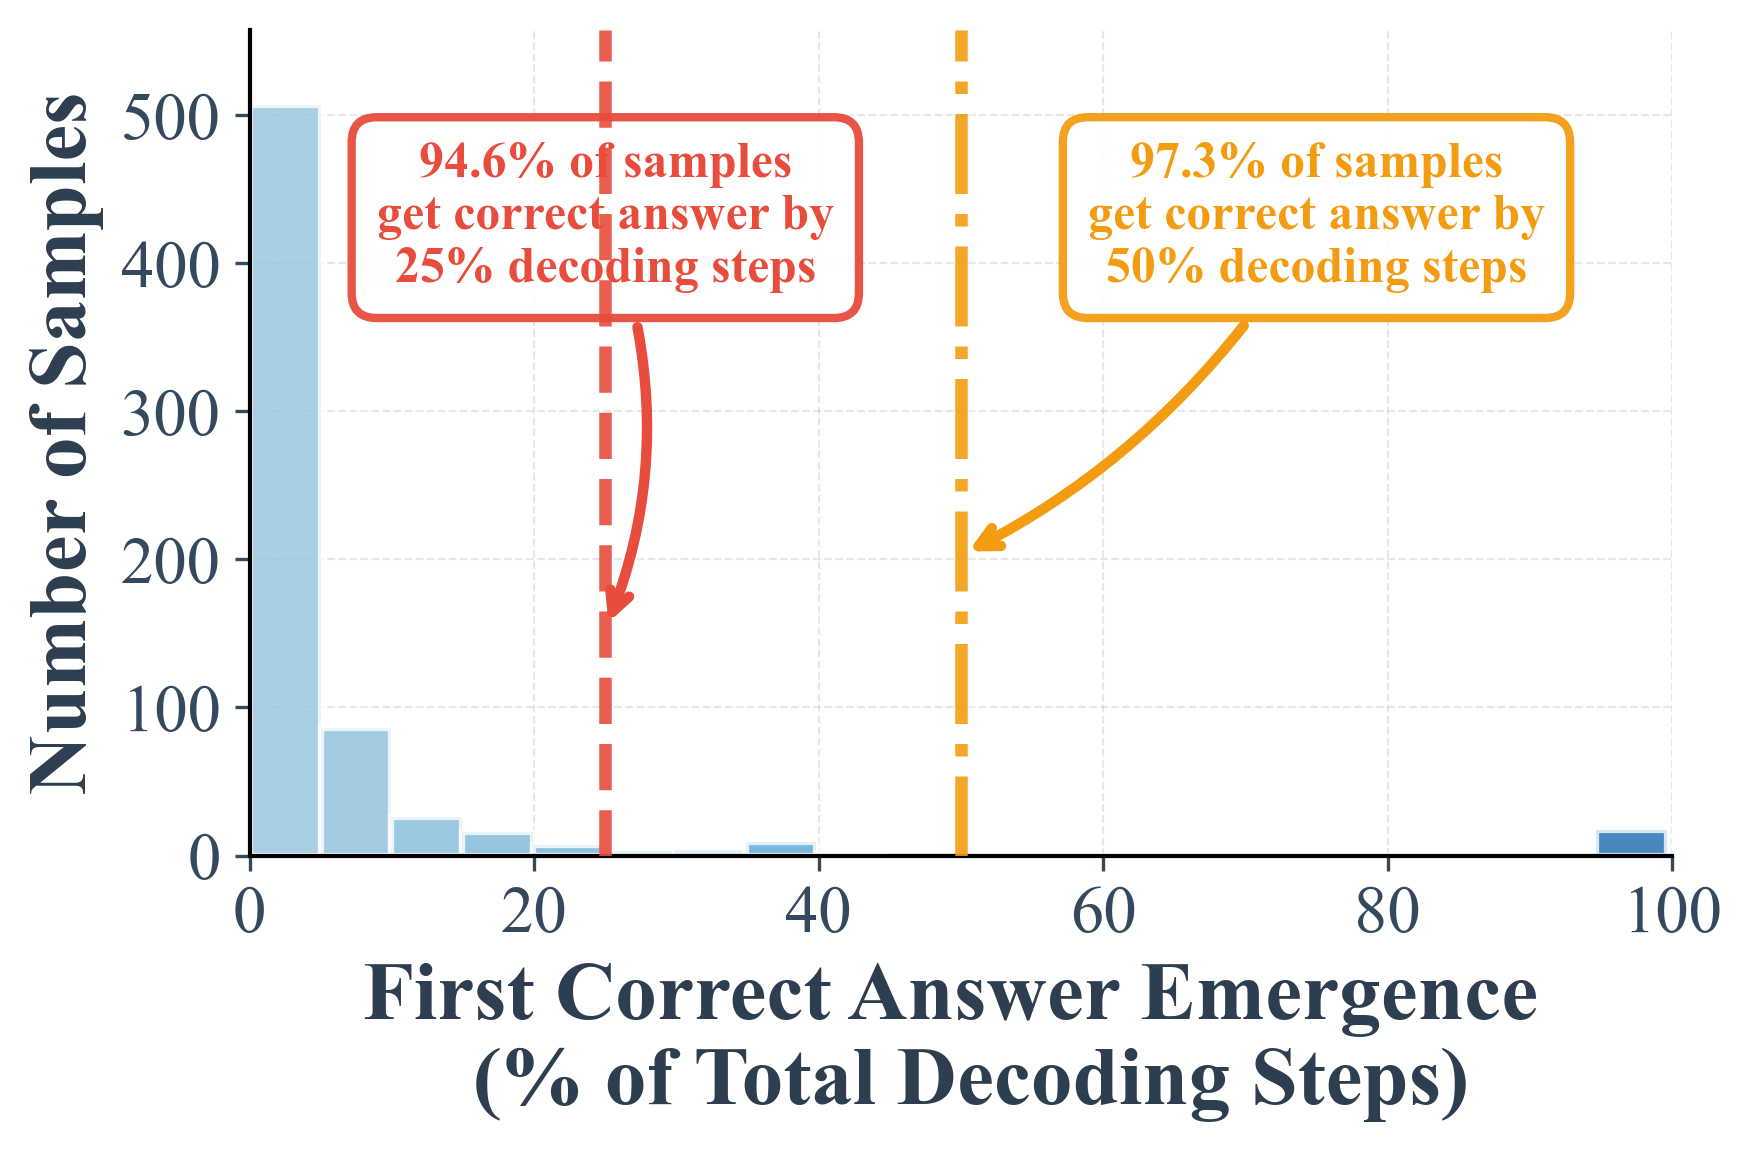

In [ ]:
GSM8K_COUNT=1319
correct_early_results_random = []
correct_early_results_dict_random = []
correct_count = 0
for q_i in range(GSM8K_COUNT):
    path = f'./question_histories_random_constraint_index_genlen_step256_blocklen256/question_{q_i:04}_steps_256.pt'
    question_dict = torch.load(path)
    x0_history_blocks = question_dict['x0_history']
    all_steps = torch.cat(x0_history_blocks, dim=0) 
    
    extracted_ans = extract_answer_from_prediction(question_dict['pred_text'])
    
    if_correct = extracted_ans == normalize_number(question_dict['gt_text'])
    if if_correct:
        correct_count += 1
        
        last_index = question_dict['ans_posidx']
        pred_ans_len = len(question_dict['pred_token_id'])
        pred_token_id = question_dict['pred_token_id']
        appear_time_steps = []
        for s_i in range(all_steps.shape[0] - 1):
            cand_ans_pos_tokens = all_steps[s_i, last_index:last_index + pred_ans_len].tolist()
            if cand_ans_pos_tokens == pred_token_id:
                appear_time_steps.append(s_i)
                
        appear_time_steps.append(all_steps.shape[0] - 1)
        
        if len(appear_time_steps) > 0:
            early_results = appear_time_steps[-1] - appear_time_steps[0]
            correct_early_results_random.append(early_results)
            correct_early_results_dict_random.append((q_i, appear_time_steps))
        else:
            print(last_index, pred_ans_len, question_dict['ans_posidx'])
            

total_timestep = 256

# Create the figure with better proportions
fig, ax = plt.subplots(figsize=(6, 4), dpi=300)

# Create histogram with improved styling and more fine-grained bins
n, bins, patches = ax.hist(
    [(item[1][0] / total_timestep) * 100 for item in correct_early_results_dict_random], 
    bins=20,  # Increased from 10 to 20 for more fine-grained bins
    edgecolor='white', 
    linewidth=1.5,
    alpha=0.8,
    color='#4A90E2',  # Professional blue
    density=False
)

# Enhance the bars with gradient effect
for i, patch in enumerate(patches):
    patch.set_facecolor(plt.cm.Blues(0.4 + 0.4 * (i / len(patches))))

# Calculate cumulative statistics
correct_early_results_pct = [(item[1][0] / total_timestep) * 100 for item in correct_early_results_dict_random]
sorted_pct = np.sort(correct_early_results_pct)
total_samples = len(correct_early_results_pct)

# Fix specific decoding step thresholds and calculate what % of samples achieve correct answers by then
threshold_1 = 25.0  # 25% of decoding steps
threshold_2 = 50.0  # 50% of decoding steps

# Calculate percentage of samples that achieve correct answers by each threshold
samples_by_1 = np.sum(np.array(correct_early_results_pct) <= threshold_1) / total_samples * 100
samples_by_2 = np.sum(np.array(correct_early_results_pct) <= threshold_2) / total_samples * 100

# Add vertical lines for fixed thresholds
ax.axvline(threshold_1, color='#E74C3C', linestyle='--', linewidth=3, 
           alpha=0.9, zorder=5)
ax.axvline(threshold_2, color='#F39C12', linestyle='-.', linewidth=3, 
           alpha=0.9, zorder=5)

# Add annotation for 50% threshold
ax.annotate(f'{samples_by_1:.1f}% of samples\nget correct answer by\n{threshold_1:.0f}% decoding steps', 
            xy=(threshold_1, max(n)*0.3), 
            xytext=(25, max(n)*0.85),  # Position in upper left white area
            arrowprops=dict(arrowstyle='->', color='#E74C3C', lw=2.5, 
                          connectionstyle="arc3,rad=-0.2"),
            fontsize=12, fontweight='bold', color='#E74C3C',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', 
                     edgecolor='#E74C3C', linewidth=2, alpha=0.95),
            ha='center', va='center')

# Add annotation for 70% threshold
ax.annotate(f'{samples_by_2:.1f}% of samples\nget correct answer by\n{threshold_2:.0f}% decoding steps', 
            xy=(threshold_2, max(n)*0.4), 
            xytext=(75, max(n)*0.85),  # Position below the first annotation
            arrowprops=dict(arrowstyle='->', color='#F39C12', lw=2.5, 
                          connectionstyle="arc3,rad=-0.15"),
            fontsize=12, fontweight='bold', color='#F39C12',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', 
                     edgecolor='#F39C12', linewidth=2, alpha=0.95),
            ha='center', va='center')

# Enhanced labels and title
ax.set_xlabel('First Correct Answer Emergence \n (% of Total Decoding Steps)', 
              fontsize=20, fontweight='bold', color='#2C3E50')
ax.set_ylabel('Number of Samples', 
              fontsize=20, fontweight='bold', color='#2C3E50')

# Improve tick styling
ax.tick_params(axis='both', which='major', labelsize=16, colors='#34495E')

ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax.set_axisbelow(True)

ax.set_xlim(0, 100)
ax.set_ylim(0, max(n) * 1.1)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1)
ax.spines['bottom'].set_linewidth(1)

# Adjust layout
plt.tight_layout()

# plt.savefig('figures/paper/early_correct_detection_distribution_random_blocklen256_constraint_suffix.pdf', 
#             dpi=300, bbox_inches='tight', facecolor='white')

plt.show()

  0%|          | 0/3153 [00:00<?, ?it/s]

100%|██████████| 3153/3153 [00:32<00:00, 95.89it/s] 


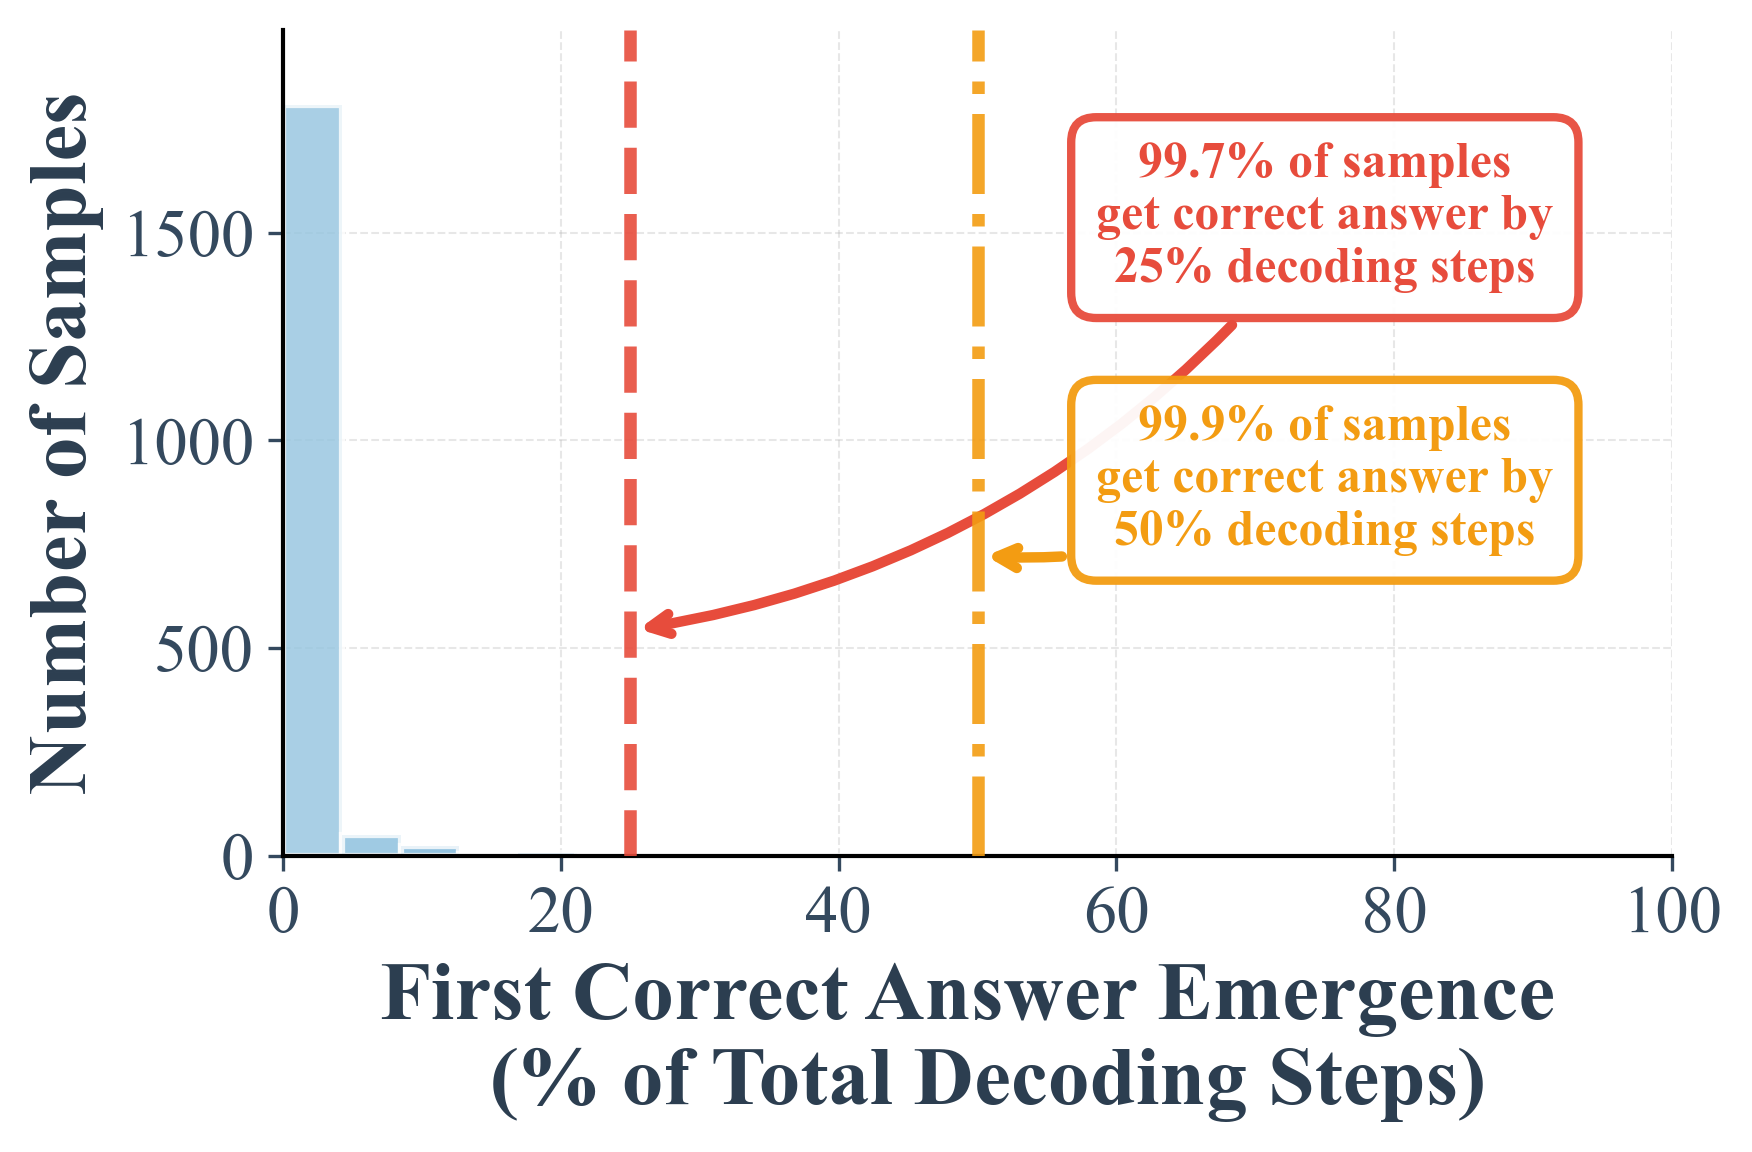

In [ ]:
MMLU_COUNT=3153
total_timestep = 128
const_policy='constraint'
decode_policy='low_confidence'
mmlu_correct_early_results_low_confidence = []
mmlu_correct_early_results_dict_low_confidence = []
correct_count = 0
for q_i in tqdm.tqdm(range(MMLU_COUNT), total=MMLU_COUNT):
    path = f'./question_histories_mmlu_{decode_policy}_{const_policy}_index_genlen_step{total_timestep}_blocklen{total_timestep}/question_{q_i:04}_steps_128.pt'
    question_dict = torch.load(path)
    x0_history_blocks = question_dict['x0_history']
    all_steps = torch.cat(x0_history_blocks, dim=0) 
    
    if_correct = question_dict['correct']
    
    if if_correct:
        correct_count += 1
        last_index = question_dict['ans_posidx']
        pred_ans_len = len(question_dict['pred_token_id'])
        pred_ans = question_dict['pred_ans']
        pred_token_id = question_dict['pred_token_id']
        appear_time_steps = []
        for s_i in range(all_steps.shape[0] - 1):
            cand_ans_pos_tokens = all_steps[s_i, last_index:last_index + pred_ans_len].tolist()
            tmp_decoded_ans = tokenizer.decode(cand_ans_pos_tokens)
            if pred_ans == tmp_decoded_ans or ' ' + pred_ans == tmp_decoded_ans:
                appear_time_steps.append(s_i)
                
        appear_time_steps.append(all_steps.shape[0] - 1)
        
        if len(appear_time_steps) > 0:
            early_results = appear_time_steps[-1] - appear_time_steps[0]
            mmlu_correct_early_results_low_confidence.append(early_results)
            mmlu_correct_early_results_dict_low_confidence.append((q_i, appear_time_steps))
        else:
            print('otherwise', q_i, last_index, pred_ans_len, question_dict['ans_posidx'])
            


# Create the figure with better proportions
fig, ax = plt.subplots(figsize=(6, 4), dpi=300)

# print(len([(item[1][0] / total_timestep) * 100 for item in mmlu_correct_early_results_dict_low_confidence]))
# Create histogram with improved styling and more fine-grained bins
n, bins, patches = ax.hist(
    [(item[1][0] / total_timestep) * 100 for item in mmlu_correct_early_results_dict_low_confidence], 
    bins='auto',  # Increased from 10 to 20 for more fine-grained bins
    edgecolor='white', 
    linewidth=1.5,
    alpha=0.8,
    color='#4A90E2',  # Professional blue
    density=False
)

# Enhance the bars with gradient effect
for i, patch in enumerate(patches):
    patch.set_facecolor(plt.cm.Blues(0.4 + 0.4 * (i / len(patches))))

# Calculate cumulative statistics
correct_early_results_pct = [(item[1][0] / total_timestep) * 100 for item in mmlu_correct_early_results_dict_low_confidence]
sorted_pct = np.sort(correct_early_results_pct)
total_samples = len(correct_early_results_pct)

# Fix specific decoding step thresholds and calculate what % of samples achieve correct answers by then
threshold_1 = 25.0  # 25% of decoding steps
threshold_2 = 50.0  # 50% of decoding steps

# Calculate percentage of samples that achieve correct answers by each threshold
samples_by_1 = np.sum(np.array(correct_early_results_pct) <= threshold_1) / total_samples * 100
samples_by_2 = np.sum(np.array(correct_early_results_pct) <= threshold_2) / total_samples * 100

# Add vertical lines for fixed thresholds
ax.axvline(threshold_1, color='#E74C3C', linestyle='--', linewidth=3, 
           alpha=0.9, zorder=5)
ax.axvline(threshold_2, color='#F39C12', linestyle='-.', linewidth=3, 
           alpha=0.9, zorder=5)

# Add annotation for 50% threshold
ax.annotate(f'{samples_by_1:.1f}% of samples\nget correct answer by\n{threshold_1:.0f}% decoding steps', 
            xy=(threshold_1, max(n)*0.3), 
            xytext=(75, max(n)*0.85),  # Position in upper left white area
            arrowprops=dict(arrowstyle='->', color='#E74C3C', lw=2.5, 
                          connectionstyle="arc3,rad=-0.2"),
            fontsize=12, fontweight='bold', color='#E74C3C',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', 
                     edgecolor='#E74C3C', linewidth=2, alpha=0.95),
            ha='center', va='center')

# Add annotation for 70% threshold
ax.annotate(f'{samples_by_2:.1f}% of samples\nget correct answer by\n{threshold_2:.0f}% decoding steps', 
            xy=(threshold_2, max(n)*0.4), 
            xytext=(75, max(n)*0.5),  # Position below the first annotation
            arrowprops=dict(arrowstyle='->', color='#F39C12', lw=2.5, 
                          connectionstyle="arc3,rad=-0.15"),
            fontsize=12, fontweight='bold', color='#F39C12',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', 
                     edgecolor='#F39C12', linewidth=2, alpha=0.95),
            ha='center', va='center')

# Enhanced labels and title
ax.set_xlabel('First Correct Answer Emergence \n (% of Total Decoding Steps)', 
              fontsize=20, fontweight='bold', color='#2C3E50')
ax.set_ylabel('Number of Samples', 
              fontsize=20, fontweight='bold', color='#2C3E50')

# Improve tick styling
ax.tick_params(axis='both', which='major', labelsize=16, colors='#34495E')

ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax.set_axisbelow(True)

ax.set_xlim(0, 100)
ax.set_ylim(0, max(n) * 1.1)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1)
ax.spines['bottom'].set_linewidth(1)

# Adjust layout
plt.tight_layout()

# plt.savefig(f'figures/paper/mmlu_early_correct_detection_distribution_{decode_policy}_{const_policy}.pdf', 
#             dpi=300, bbox_inches='tight', facecolor='white')

plt.show()


100%|██████████| 3153/3153 [00:30<00:00, 103.75it/s]


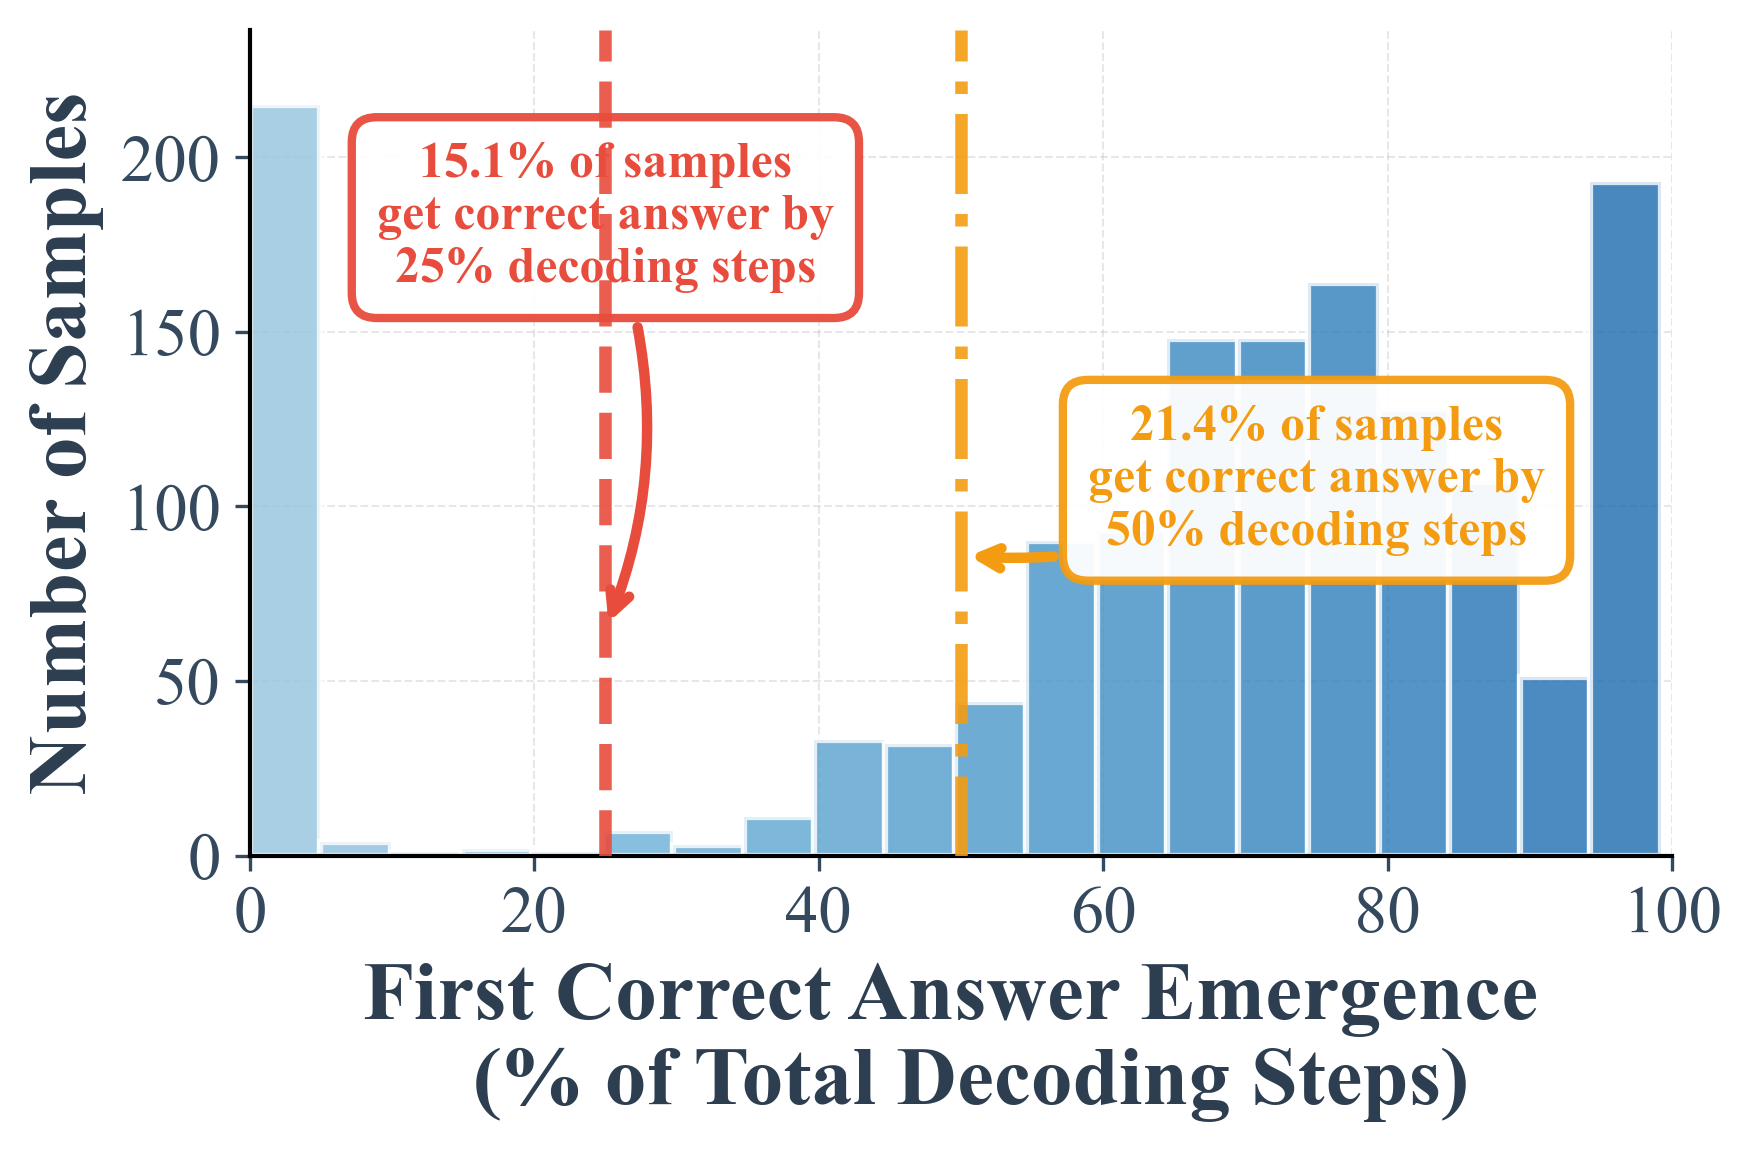

In [ ]:
MMLU_COUNT=3153
total_timestep = 128
const_policy='none'
decode_policy='low_confidence'
mmlu_correct_early_results_low_confidence = []
mmlu_correct_early_results_dict_low_confidence = []
correct_count = 0
for q_i in tqdm.tqdm(range(MMLU_COUNT), total=MMLU_COUNT):
    path = f'./question_histories_mmlu_{decode_policy}_{const_policy}_index_genlen_step{total_timestep}_blocklen{total_timestep}/question_{q_i:04}_steps_128.pt'
    question_dict = torch.load(path)
    x0_history_blocks = question_dict['x0_history']
    all_steps = torch.cat(x0_history_blocks, dim=0) 
    
    if_correct = question_dict['correct']
    
    if if_correct:
        correct_count += 1
        last_index = question_dict['ans_posidx']
        pred_ans_len = len(question_dict['pred_token_id'])
        pred_ans = question_dict['pred_ans']
        pred_token_id = question_dict['pred_token_id']
        appear_time_steps = []
        for s_i in range(all_steps.shape[0] - 1):
            cand_ans_pos_tokens = all_steps[s_i, last_index:last_index + pred_ans_len].tolist()
            tmp_decoded_ans = tokenizer.decode(cand_ans_pos_tokens)
            if pred_ans == tmp_decoded_ans or ' ' + pred_ans == tmp_decoded_ans:
                appear_time_steps.append(s_i)
                
        appear_time_steps.append(all_steps.shape[0] - 1)
        
        if len(appear_time_steps) > 0:
            early_results = appear_time_steps[-1] - appear_time_steps[0]
            mmlu_correct_early_results_low_confidence.append(early_results)
            mmlu_correct_early_results_dict_low_confidence.append((q_i, appear_time_steps))
        else:
            print('otherwise', q_i, last_index, pred_ans_len, question_dict['ans_posidx'])
            


# Create the figure with better proportions
fig, ax = plt.subplots(figsize=(6, 4), dpi=300)

# print(len([(item[1][0] / total_timestep) * 100 for item in mmlu_correct_early_results_dict_low_confidence]))
# Create histogram with improved styling and more fine-grained bins
n, bins, patches = ax.hist(
    [(item[1][0] / total_timestep) * 100 for item in mmlu_correct_early_results_dict_low_confidence], 
    bins=20,  # Increased from 10 to 20 for more fine-grained bins
    edgecolor='white', 
    linewidth=1.5,
    alpha=0.8,
    color='#4A90E2',  # Professional blue
    density=False
)

# Enhance the bars with gradient effect
for i, patch in enumerate(patches):
    patch.set_facecolor(plt.cm.Blues(0.4 + 0.4 * (i / len(patches))))

# Calculate cumulative statistics
correct_early_results_pct = [(item[1][0] / total_timestep) * 100 for item in mmlu_correct_early_results_dict_low_confidence]
sorted_pct = np.sort(correct_early_results_pct)
total_samples = len(correct_early_results_pct)

# Fix specific decoding step thresholds and calculate what % of samples achieve correct answers by then
threshold_1 = 25.0  # 25% of decoding steps
threshold_2 = 50.0  # 50% of decoding steps

# Calculate percentage of samples that achieve correct answers by each threshold
samples_by_1 = np.sum(np.array(correct_early_results_pct) <= threshold_1) / total_samples * 100
samples_by_2 = np.sum(np.array(correct_early_results_pct) <= threshold_2) / total_samples * 100

# Add vertical lines for fixed thresholds
ax.axvline(threshold_1, color='#E74C3C', linestyle='--', linewidth=3, 
           alpha=0.9, zorder=5)
ax.axvline(threshold_2, color='#F39C12', linestyle='-.', linewidth=3, 
           alpha=0.9, zorder=5)

# Add annotation for 50% threshold
ax.annotate(f'{samples_by_1:.1f}% of samples\nget correct answer by\n{threshold_1:.0f}% decoding steps', 
            xy=(threshold_1, max(n)*0.3), 
            xytext=(25, max(n)*0.85),  # Position in upper left white area
            arrowprops=dict(arrowstyle='->', color='#E74C3C', lw=2.5, 
                          connectionstyle="arc3,rad=-0.2"),
            fontsize=12, fontweight='bold', color='#E74C3C',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', 
                     edgecolor='#E74C3C', linewidth=2, alpha=0.95),
            ha='center', va='center')

# Add annotation for 70% threshold
ax.annotate(f'{samples_by_2:.1f}% of samples\nget correct answer by\n{threshold_2:.0f}% decoding steps', 
            xy=(threshold_2, max(n)*0.4), 
            xytext=(75, max(n)*0.5),  # Position below the first annotation
            arrowprops=dict(arrowstyle='->', color='#F39C12', lw=2.5, 
                          connectionstyle="arc3,rad=-0.15"),
            fontsize=12, fontweight='bold', color='#F39C12',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', 
                     edgecolor='#F39C12', linewidth=2, alpha=0.95),
            ha='center', va='center')

# Enhanced labels and title
ax.set_xlabel('First Correct Answer Emergence \n (% of Total Decoding Steps)', 
              fontsize=20, fontweight='bold', color='#2C3E50')
ax.set_ylabel('Number of Samples', 
              fontsize=20, fontweight='bold', color='#2C3E50')

# Improve tick styling
ax.tick_params(axis='both', which='major', labelsize=16, colors='#34495E')

ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax.set_axisbelow(True)

ax.set_xlim(0, 100)
ax.set_ylim(0, max(n) * 1.1)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1)
ax.spines['bottom'].set_linewidth(1)

# Adjust layout
plt.tight_layout()

plt.savefig(f'figures/paper/mmlu_early_correct_detection_distribution_{decode_policy}_{const_policy}.pdf', 
            dpi=300, bbox_inches='tight', facecolor='white')



100%|██████████| 3153/3153 [00:30<00:00, 103.53it/s]


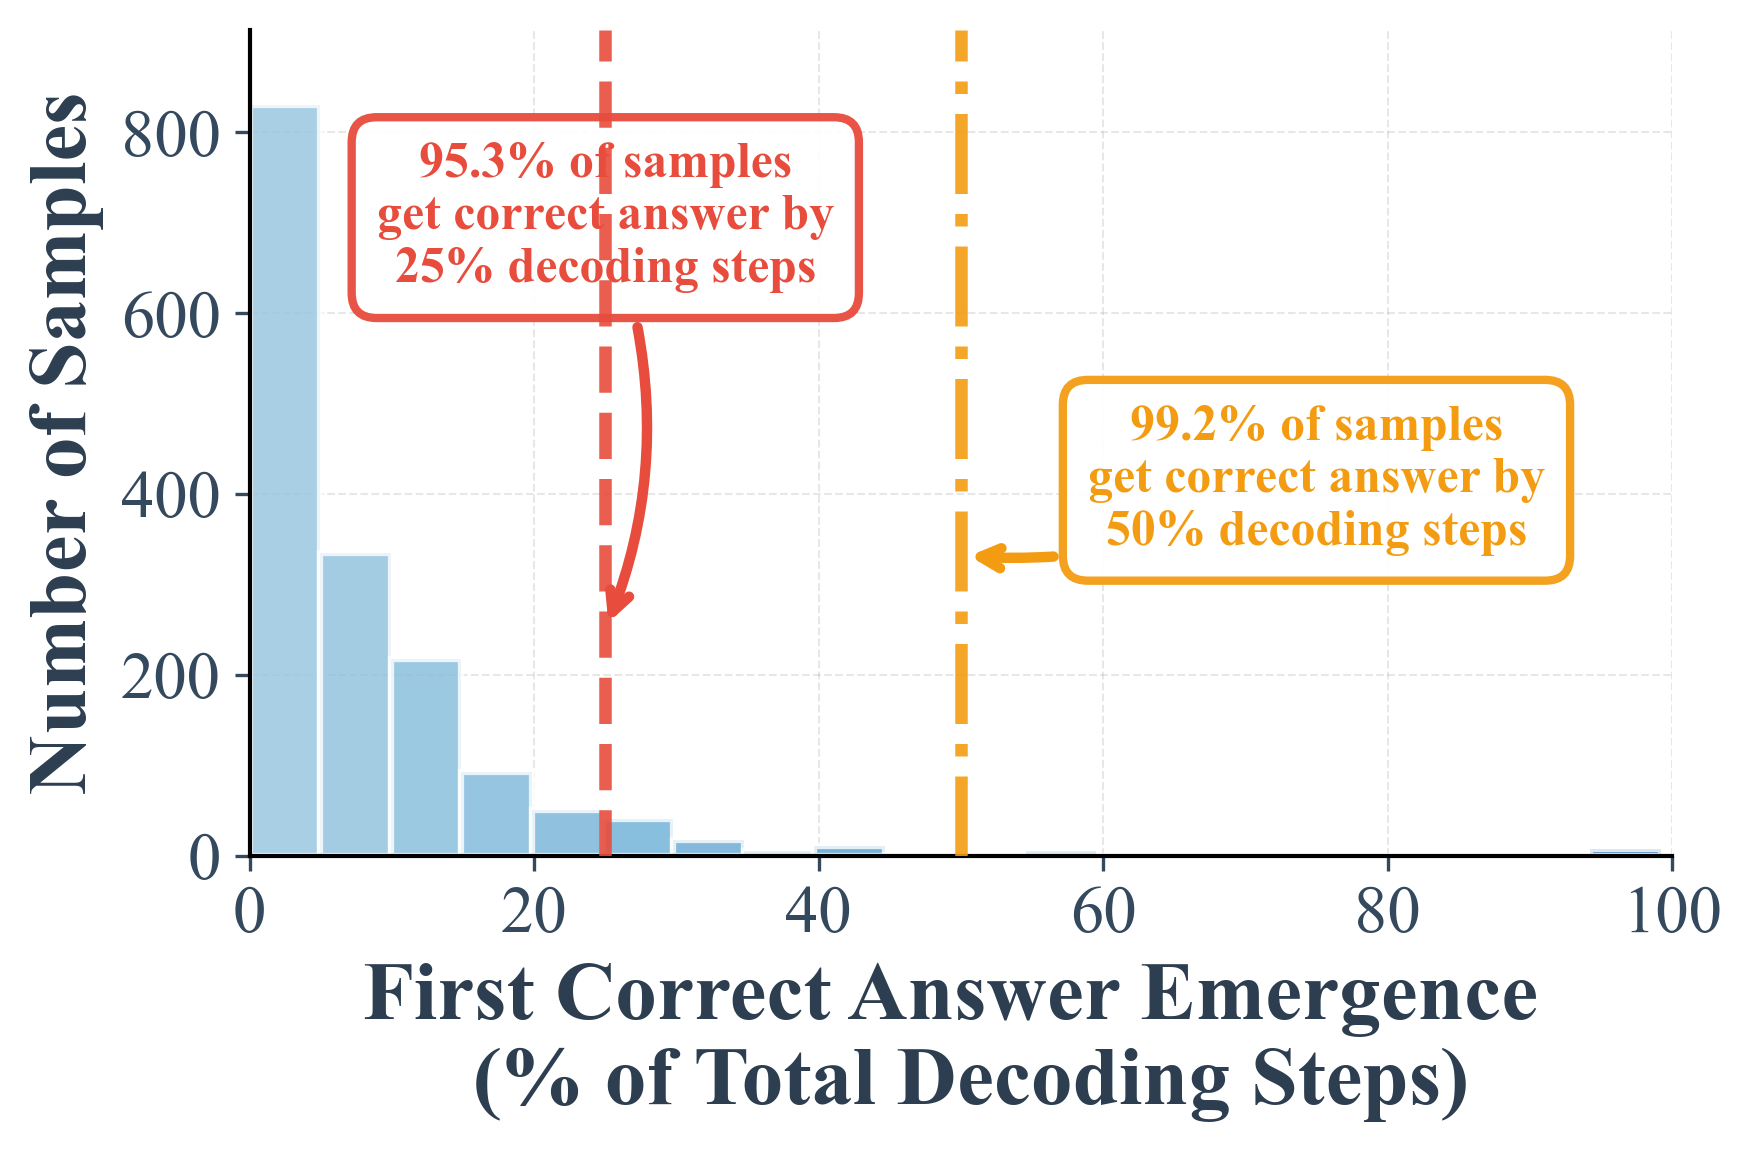

In [ ]:
MMLU_COUNT=3153
total_timestep = 128
const_policy='none'
decode_policy='random'
mmlu_correct_early_results_low_confidence = []
mmlu_correct_early_results_dict_low_confidence = []
correct_count = 0
for q_i in tqdm.tqdm(range(MMLU_COUNT), total=MMLU_COUNT):
    path = f'./question_histories_mmlu_{decode_policy}_{const_policy}_index_genlen_step{total_timestep}_blocklen{total_timestep}/question_{q_i:04}_steps_128.pt'
    question_dict = torch.load(path)
    x0_history_blocks = question_dict['x0_history']
    all_steps = torch.cat(x0_history_blocks, dim=0) 
    
    if_correct = question_dict['correct']
    
    if if_correct:
        correct_count += 1
        last_index = question_dict['ans_posidx']
        pred_ans_len = len(question_dict['pred_token_id'])
        pred_ans = question_dict['pred_ans']
        pred_token_id = question_dict['pred_token_id']
        appear_time_steps = []
        for s_i in range(all_steps.shape[0] - 1):
            cand_ans_pos_tokens = all_steps[s_i, last_index:last_index + pred_ans_len].tolist()
            tmp_decoded_ans = tokenizer.decode(cand_ans_pos_tokens)
            if pred_ans == tmp_decoded_ans or ' ' + pred_ans == tmp_decoded_ans:
                appear_time_steps.append(s_i)
                
        appear_time_steps.append(all_steps.shape[0] - 1)
        
        if len(appear_time_steps) > 0:
            early_results = appear_time_steps[-1] - appear_time_steps[0]
            mmlu_correct_early_results_low_confidence.append(early_results)
            mmlu_correct_early_results_dict_low_confidence.append((q_i, appear_time_steps))
        else:
            print('otherwise', q_i, last_index, pred_ans_len, question_dict['ans_posidx'])
            


# Create the figure with better proportions
fig, ax = plt.subplots(figsize=(6, 4), dpi=300)

# print(len([(item[1][0] / total_timestep) * 100 for item in mmlu_correct_early_results_dict_low_confidence]))
# Create histogram with improved styling and more fine-grained bins
n, bins, patches = ax.hist(
    [(item[1][0] / total_timestep) * 100 for item in mmlu_correct_early_results_dict_low_confidence], 
    bins=20,  # Increased from 10 to 20 for more fine-grained bins
    edgecolor='white', 
    linewidth=1.5,
    alpha=0.8,
    color='#4A90E2',  # Professional blue
    density=False
)

# Enhance the bars with gradient effect
for i, patch in enumerate(patches):
    patch.set_facecolor(plt.cm.Blues(0.4 + 0.4 * (i / len(patches))))

# Calculate cumulative statistics
correct_early_results_pct = [(item[1][0] / total_timestep) * 100 for item in mmlu_correct_early_results_dict_low_confidence]
sorted_pct = np.sort(correct_early_results_pct)
total_samples = len(correct_early_results_pct)

# Fix specific decoding step thresholds and calculate what % of samples achieve correct answers by then
threshold_1 = 25.0  # 25% of decoding steps
threshold_2 = 50.0  # 50% of decoding steps

# Calculate percentage of samples that achieve correct answers by each threshold
samples_by_1 = np.sum(np.array(correct_early_results_pct) <= threshold_1) / total_samples * 100
samples_by_2 = np.sum(np.array(correct_early_results_pct) <= threshold_2) / total_samples * 100

# Add vertical lines for fixed thresholds
ax.axvline(threshold_1, color='#E74C3C', linestyle='--', linewidth=3, 
           alpha=0.9, zorder=5)
ax.axvline(threshold_2, color='#F39C12', linestyle='-.', linewidth=3, 
           alpha=0.9, zorder=5)

# Add annotation for 50% threshold
ax.annotate(f'{samples_by_1:.1f}% of samples\nget correct answer by\n{threshold_1:.0f}% decoding steps', 
            xy=(threshold_1, max(n)*0.3), 
            xytext=(25, max(n)*0.85),  # Position in upper left white area
            arrowprops=dict(arrowstyle='->', color='#E74C3C', lw=2.5, 
                          connectionstyle="arc3,rad=-0.2"),
            fontsize=12, fontweight='bold', color='#E74C3C',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', 
                     edgecolor='#E74C3C', linewidth=2, alpha=0.95),
            ha='center', va='center')

# Add annotation for 70% threshold
ax.annotate(f'{samples_by_2:.1f}% of samples\nget correct answer by\n{threshold_2:.0f}% decoding steps', 
            xy=(threshold_2, max(n)*0.4), 
            xytext=(75, max(n)*0.5),  # Position below the first annotation
            arrowprops=dict(arrowstyle='->', color='#F39C12', lw=2.5, 
                          connectionstyle="arc3,rad=-0.15"),
            fontsize=12, fontweight='bold', color='#F39C12',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', 
                     edgecolor='#F39C12', linewidth=2, alpha=0.95),
            ha='center', va='center')

# Enhanced labels and title
ax.set_xlabel('First Correct Answer Emergence \n (% of Total Decoding Steps)', 
              fontsize=20, fontweight='bold', color='#2C3E50')
ax.set_ylabel('Number of Samples', 
              fontsize=20, fontweight='bold', color='#2C3E50')

# Improve tick styling
ax.tick_params(axis='both', which='major', labelsize=16, colors='#34495E')

ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax.set_axisbelow(True)

ax.set_xlim(0, 100)
ax.set_ylim(0, max(n) * 1.1)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1)
ax.spines['bottom'].set_linewidth(1)

# Adjust layout
plt.tight_layout()

plt.savefig(f'figures/paper/mmlu_early_correct_detection_distribution_{decode_policy}_{const_policy}.pdf', 
            dpi=300, bbox_inches='tight', facecolor='white')



100%|██████████| 3153/3153 [00:30<00:00, 102.71it/s]


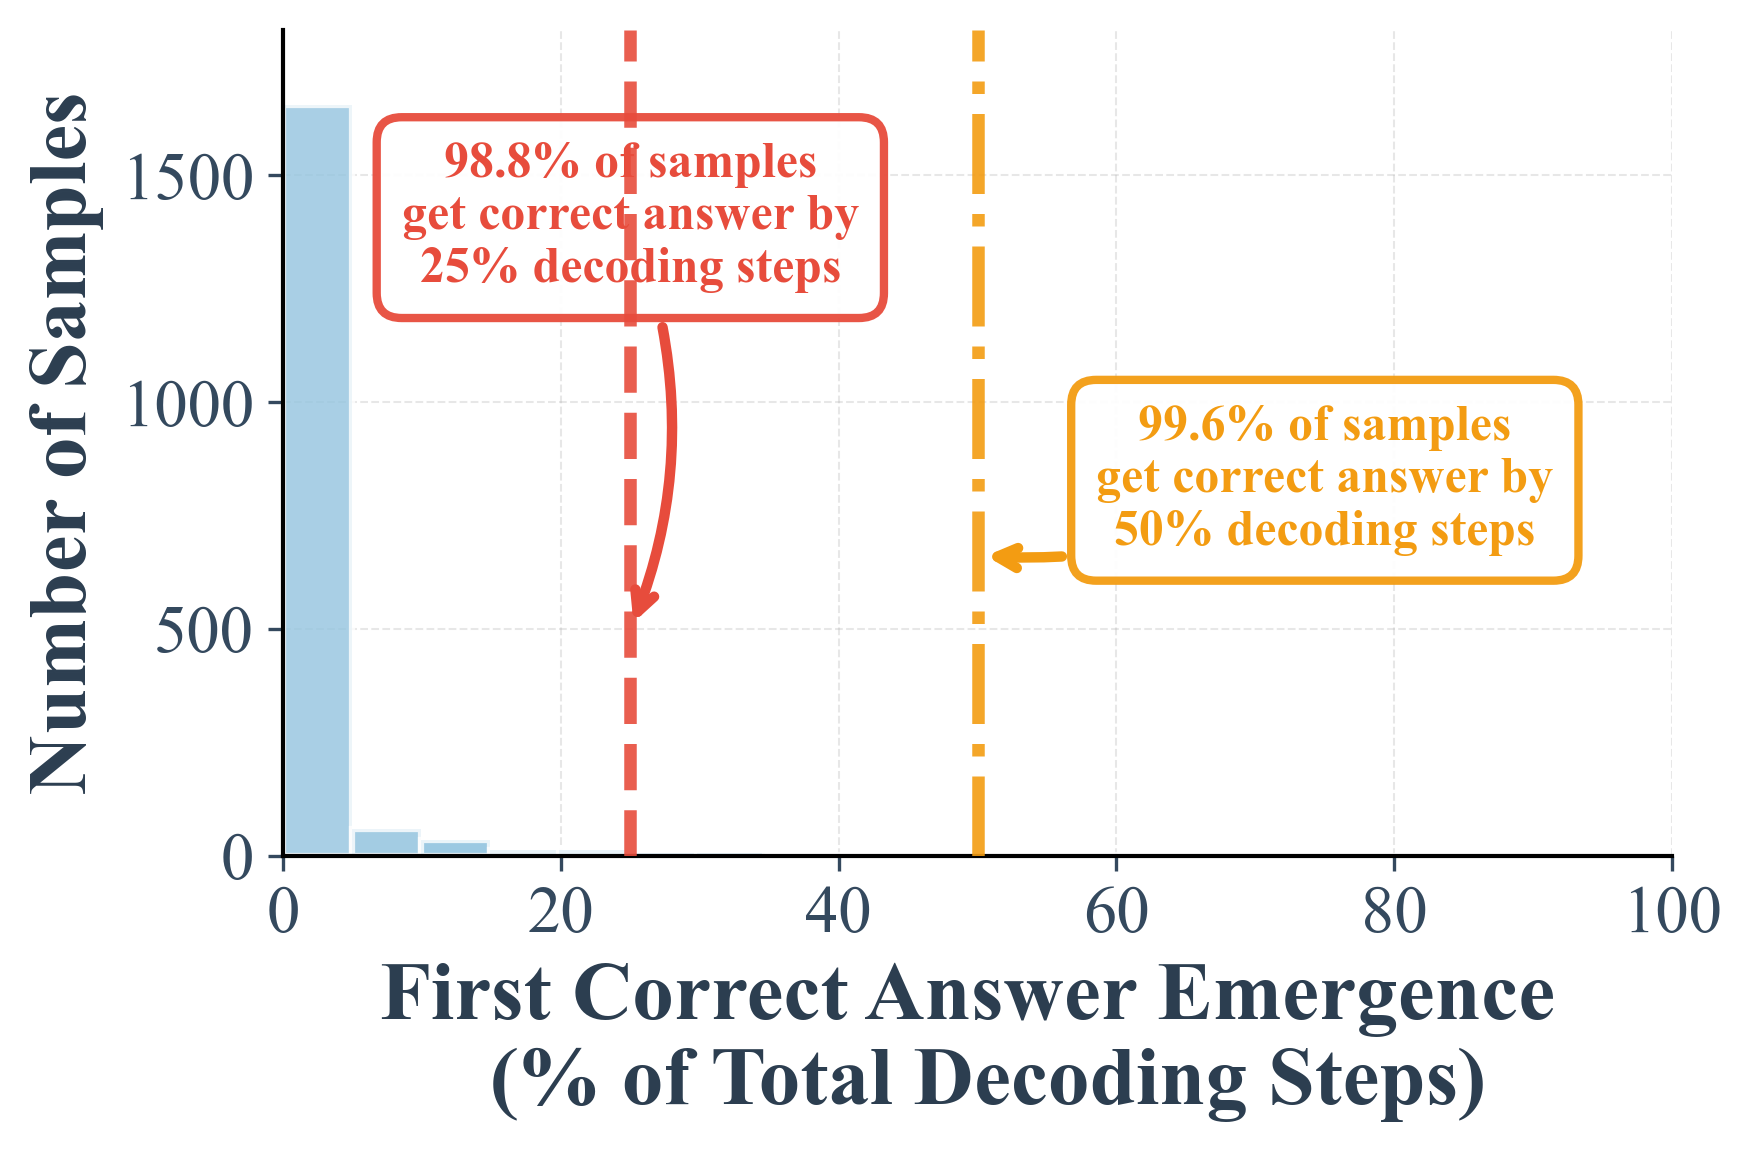

In [ ]:
MMLU_COUNT=3153
total_timestep = 128
const_policy='constraint'
decode_policy='random'
mmlu_correct_early_results_low_confidence = []
mmlu_correct_early_results_dict_low_confidence = []
correct_count = 0
for q_i in tqdm.tqdm(range(MMLU_COUNT), total=MMLU_COUNT):
    path = f'./question_histories_mmlu_{decode_policy}_{const_policy}_index_genlen_step{total_timestep}_blocklen{total_timestep}/question_{q_i:04}_steps_128.pt'
    question_dict = torch.load(path)
    x0_history_blocks = question_dict['x0_history']
    all_steps = torch.cat(x0_history_blocks, dim=0) 
    
    if_correct = question_dict['correct']
    
    if if_correct:
        correct_count += 1
        last_index = question_dict['ans_posidx']
        pred_ans_len = len(question_dict['pred_token_id'])
        pred_ans = question_dict['pred_ans']
        pred_token_id = question_dict['pred_token_id']
        appear_time_steps = []
        for s_i in range(all_steps.shape[0] - 1):
            cand_ans_pos_tokens = all_steps[s_i, last_index:last_index + pred_ans_len].tolist()
            tmp_decoded_ans = tokenizer.decode(cand_ans_pos_tokens)
            if pred_ans == tmp_decoded_ans or ' ' + pred_ans == tmp_decoded_ans:
                appear_time_steps.append(s_i)
                
        appear_time_steps.append(all_steps.shape[0] - 1)
        
        if len(appear_time_steps) > 0:
            early_results = appear_time_steps[-1] - appear_time_steps[0]
            mmlu_correct_early_results_low_confidence.append(early_results)
            mmlu_correct_early_results_dict_low_confidence.append((q_i, appear_time_steps))
        else:
            print('otherwise', q_i, last_index, pred_ans_len, question_dict['ans_posidx'])
            


# Create the figure with better proportions
fig, ax = plt.subplots(figsize=(6, 4), dpi=300)

# print(len([(item[1][0] / total_timestep) * 100 for item in mmlu_correct_early_results_dict_low_confidence]))
# Create histogram with improved styling and more fine-grained bins
n, bins, patches = ax.hist(
    [(item[1][0] / total_timestep) * 100 for item in mmlu_correct_early_results_dict_low_confidence], 
    bins=20,  # Increased from 10 to 20 for more fine-grained bins
    edgecolor='white', 
    linewidth=1.5,
    alpha=0.8,
    color='#4A90E2',  # Professional blue
    density=False
)

# Enhance the bars with gradient effect
for i, patch in enumerate(patches):
    patch.set_facecolor(plt.cm.Blues(0.4 + 0.4 * (i / len(patches))))

# Calculate cumulative statistics
correct_early_results_pct = [(item[1][0] / total_timestep) * 100 for item in mmlu_correct_early_results_dict_low_confidence]
sorted_pct = np.sort(correct_early_results_pct)
total_samples = len(correct_early_results_pct)

# Fix specific decoding step thresholds and calculate what % of samples achieve correct answers by then
threshold_1 = 25.0  # 25% of decoding steps
threshold_2 = 50.0  # 50% of decoding steps

# Calculate percentage of samples that achieve correct answers by each threshold
samples_by_1 = np.sum(np.array(correct_early_results_pct) <= threshold_1) / total_samples * 100
samples_by_2 = np.sum(np.array(correct_early_results_pct) <= threshold_2) / total_samples * 100

# Add vertical lines for fixed thresholds
ax.axvline(threshold_1, color='#E74C3C', linestyle='--', linewidth=3, 
           alpha=0.9, zorder=5)
ax.axvline(threshold_2, color='#F39C12', linestyle='-.', linewidth=3, 
           alpha=0.9, zorder=5)

# Add annotation for 50% threshold
ax.annotate(f'{samples_by_1:.1f}% of samples\nget correct answer by\n{threshold_1:.0f}% decoding steps', 
            xy=(threshold_1, max(n)*0.3), 
            xytext=(25, max(n)*0.85),  # Position in upper left white area
            arrowprops=dict(arrowstyle='->', color='#E74C3C', lw=2.5, 
                          connectionstyle="arc3,rad=-0.2"),
            fontsize=12, fontweight='bold', color='#E74C3C',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', 
                     edgecolor='#E74C3C', linewidth=2, alpha=0.95),
            ha='center', va='center')

# Add annotation for 70% threshold
ax.annotate(f'{samples_by_2:.1f}% of samples\nget correct answer by\n{threshold_2:.0f}% decoding steps', 
            xy=(threshold_2, max(n)*0.4), 
            xytext=(75, max(n)*0.5),  # Position below the first annotation
            arrowprops=dict(arrowstyle='->', color='#F39C12', lw=2.5, 
                          connectionstyle="arc3,rad=-0.15"),
            fontsize=12, fontweight='bold', color='#F39C12',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', 
                     edgecolor='#F39C12', linewidth=2, alpha=0.95),
            ha='center', va='center')

# Enhanced labels and title
ax.set_xlabel('First Correct Answer Emergence \n (% of Total Decoding Steps)', 
              fontsize=20, fontweight='bold', color='#2C3E50')
ax.set_ylabel('Number of Samples', 
              fontsize=20, fontweight='bold', color='#2C3E50')

# Improve tick styling
ax.tick_params(axis='both', which='major', labelsize=16, colors='#34495E')

ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax.set_axisbelow(True)

ax.set_xlim(0, 100)
ax.set_ylim(0, max(n) * 1.1)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1)
ax.spines['bottom'].set_linewidth(1)

# Adjust layout
plt.tight_layout()

plt.savefig(f'figures/paper/mmlu_early_correct_detection_distribution_{decode_policy}_{const_policy}.pdf', 
            dpi=300, bbox_inches='tight', facecolor='white')



In [11]:
model_path = "GSAI-ML/LLaDA-8B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(model_path, trust_remote_code=True)

In [8]:
def calculate_position_changes_over_steps(x0_history_blocks, position_slice=None):
    """
    Calculate change patterns for each position over steps.
    
    Args:
        x0_history_blocks: List of tensors [num_steps_per_block, seq_length]
        position_slice: Slice to focus on specific positions (e.g., slice(-130, None))
    
    Returns:
        position_change_matrix: Tensor [num_steps-1, num_positions] - True where position changed
        cumulative_changes_per_position: Tensor [num_positions] - total changes per position
        change_curves_per_position: Tensor [num_steps, num_positions] - cumulative changes over time
        all_tokens: Tensor [num_steps, num_positions] - all token values
    """
    
    # Concatenate all blocks to get full sequence
    all_steps = torch.cat(x0_history_blocks, dim=0)  # Shape: [num_steps, seq_length]
    
    if position_slice is not None:
        all_steps = all_steps[:, position_slice]
    
    num_steps, num_positions = all_steps.shape
    print(f"Analyzing {num_positions} positions over {num_steps} steps")
    
    # Calculate changes between consecutive steps for each position
    position_change_matrix = torch.zeros(num_steps - 1, num_positions, dtype=torch.bool)
    
    for step in range(num_steps - 1):
        position_change_matrix[step] = (all_steps[step] != all_steps[step + 1])
    
    # Calculate cumulative changes over time for each position
    change_curves_per_position = torch.zeros(num_steps, num_positions)
    
    for step in range(1, num_steps):
        # Cumulative sum of changes up to this step
        change_curves_per_position[step] = position_change_matrix[:step].sum(dim=0).float()
    
    # Total changes per position
    cumulative_changes_per_position = position_change_matrix.sum(dim=0).float()
    
    return (position_change_matrix, cumulative_changes_per_position, 
            change_curves_per_position, all_steps)

def analyze_question_position_changes(path='question_histories/question_0000_steps_128.pt',
                                      split='test',
                                      truncated_after_prompt=200,
                                      truncated_at_end=None,
                                      save_path=None):
    """
    Main function to analyze position changes for your question data.
    """
    dataframe = torch.load(path)
    
    (change_matrix, total_changes, change_curves, all_tokens) = \
                    calculate_position_changes_over_steps(
                            dataframe['x0_history'], 
                            position_slice=None
                        )
    trace_history = dataframe['true_indices_history']
    
    print('Answer index', dataframe['ans_posidx'], 'correct or not:', dataframe['correct'])
    plot_position_change_heatmap_ans_token(change_matrix, true_indices_history=trace_history, 
                                 save_path=save_path,
                                 ans_token_idx=dataframe['ans_posidx'],
                                 prompt_token_len=dataframe['prompt_token_len'],
                                 truncated_after_prompt=truncated_after_prompt,
                                 truncated_at_end=truncated_at_end,
                                 gt_token_id_lst=dataframe['gt_token_id'],
                                 all_tokens=all_tokens
                                 )
    
    return change_matrix, total_changes, change_curves, all_tokens, dataframe

In [9]:
def plot_position_change_heatmap_ans_token(position_change_matrix, 
                                 true_indices_history=None, 
                                 save_path=None, 
                                 max_positions=50,
                                 ans_token_idx=-1,
                                 prompt_token_len=100,
                                 truncated_after_prompt=200,
                                 truncated_at_end=None,
                                 gt_token_id_lst=[],
                                 all_tokens=None):
    """
    Create a heatmap showing which positions change at which steps with better axis visualization.
    Optionally overlay true_indices_history data.
    
    Args:
        position_change_matrix: Boolean tensor of position changes [num_steps-1, num_positions]
        true_indices_history: List of tensors from question data (optional)
        save_path: Path to save the figure
        max_positions: Maximum positions to show
        ans_token_idx: Index of the answer token position to highlight in yellow
        gt_token_id_lst: List of ground truth token IDs to highlight
        all_tokens: Tensor [num_steps, num_positions] of all token values
    """
    print('gt_token_id_lst', gt_token_id_lst)
    num_steps_diff, num_positions = position_change_matrix.shape
    num_steps = num_steps_diff + 1  # Add 1 because change matrix has one fewer step
    
    # Create full step matrix by padding with zeros at the beginning (step 0 has no changes)
    full_change_matrix = torch.zeros(num_steps, num_positions, dtype=torch.bool)
    full_change_matrix[1:, :] = position_change_matrix  # Changes start from step 1
    
    heatmap_data = full_change_matrix.float()
    pos_labels = [f'Pos {i}' for i in range(num_positions)]
    pos_mapping = {i: i for i in range(num_positions)}
    
    # Create overlaid data matrix: 0=no change, 1=position changed, 2=true_indices, 3=ans_token
    overlay_data = heatmap_data.clone()
    print('overlay_data', overlay_data.shape, 'all_tokens', all_tokens.shape)
    
    filter_start = prompt_token_len + truncated_after_prompt
    
    # Add ground truth token sequence highlighting starting from ans_token_idx
    # Only highlight if the ENTIRE sequence matches
    print_first = False
    if ans_token_idx >= 0 and len(gt_token_id_lst) > 0 and all_tokens is not None:
        # Check each step to see if the entire sequence matches ground truth
        for step in range(num_steps):
            # Check if we can fit the entire gt sequence starting from ans_token_idx
            if ans_token_idx + len(gt_token_id_lst) <= num_positions:
                # First, check if the entire sequence matches
                if all_tokens[step, ans_token_idx:ans_token_idx + len(gt_token_id_lst)].tolist() == gt_token_id_lst:
                    if not print_first:
                        print('step', step)
                        #print(all_tokens[step, filter_start:truncated_at_end])
                        print(repr(tokenizer.decode(all_tokens[step, filter_start:truncated_at_end])))
                        print_first = True
                        
                    overlay_data[step, ans_token_idx:ans_token_idx + len(gt_token_id_lst)] = 3.0
    
    # Add true_indices_history overlay if provided
    if true_indices_history is not None:
        # Flatten true_indices_history (it's organized by blocks)
        step_counter = 0
        for block_idx, block_indices in enumerate(true_indices_history):
            for step_idx, indices_tensor in enumerate(block_indices):
                if step_counter >= num_steps:  # Don't exceed our matrix bounds
                    break
                    
                # indices_tensor should be shape [N, 2] where [:, 1] are position indices
                if len(indices_tensor) > 0:
                    position_indices = indices_tensor[:, 1]  # Get position column
                    
                    for pos_idx in position_indices:
                        pos_idx = pos_idx.item()
                        # Check if this position is in our filtered set
                        if pos_idx in pos_mapping:
                            filtered_pos_idx = pos_mapping[pos_idx]
                            # Set to 2 for true_indices (will show as different color)
                            overlay_data[step_counter, filtered_pos_idx] = 2.0
                
                step_counter += 1
            
            if step_counter >= num_steps:
                break
    
    #plt.figure(figsize=(10, 8))
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Create step labels with intervals - now using full step range
    step_interval = max(1, num_steps // 10)  # Show ~10 step labels
    step_labels = list(range(0, num_steps, step_interval))
    
    # Create custom colormap: white=0, red=1 (changed), blue=2 (decoded), yellow=3 (ans_token)
    from matplotlib.colors import ListedColormap
    colors = ['#f7f7f7',    # 0: No change - very light gray
          '#969696',    # 1: Normal token change - medium gray
          '#4292c6',    # 2: Token decoded - professional blue
          '#41ab5d']    # 3: Change to correct answer - professional green
    
    colors = ['#f8f9fa',    # 0: No change - light gray
          '#ff8c42',    # 1: Normal token change - warm orange
          '#3498db',    # 2: Token decoded - blue
          '#27ae60']    # 3: Change to correct answer - green
    cmap = ListedColormap(colors)
    
    # Apply position filtering if needed
    
    overlay_data = overlay_data[:, filter_start:truncated_at_end]
    print(f"Heatmap data shape after filtering: {overlay_data.T.shape}")
    
    # Create position labels for output tokens (accounting for truncated_after_prompt)
    num_filtered_positions = overlay_data.shape[1]
    pos_interval = max(1, num_filtered_positions // 10)  # Show ~10 position labels
    pos_tick_indices = list(range(0, num_filtered_positions, pos_interval))
    # if (num_filtered_positions - 1) not in pos_tick_indices:
    #     pos_tick_indices.append(num_filtered_positions - 1)
    
    # Output token position indices (starting from truncated_after_prompt)
    pos_tick_labels = [str(truncated_after_prompt + i) for i in pos_tick_indices]
    
    # Transpose to have positions on y-axis, steps on x-axis
    ax = sns.heatmap(overlay_data.T, 
                     xticklabels=False,  # We'll set custom ticks
                     yticklabels=False,  # We'll set custom ticks
                     cmap=cmap,
                     vmin=0, vmax=3, cbar=False
                     ) #cbar_kws={'label': 'Change Type', 'ticks': [0, 1, 2, 3]}
    
    # Set custom x-axis ticks and labels
    ax.set_xticks([i + 0.5 for i in step_labels])
    ax.set_xticklabels(step_labels, rotation=45, fontsize=15)
    
    # Set custom y-axis ticks and labels
    ax.set_yticks([i + 0.5 for i in pos_tick_indices])
    ax.set_yticklabels(pos_tick_labels, rotation=0, fontsize=15)
    
    # ax.add_patch(plt.Rectangle((0, 0), overlay_data.shape[0], overlay_data.shape[1], 
    #                        fill=False, edgecolor='#bdc3c7', linewidth=1.5))
    
    plt.xlabel('Decoding Steps', fontsize=20)
    plt.ylabel('Output Token Position Index', fontsize=20)
    plt.tight_layout(pad=2.0)
    fig.patch.set_facecolor('#ffffff')
    fig.patch.set_edgecolor('#e9ecef')
    fig.patch.set_linewidth(2)
    #plt.show()
    plt.tight_layout()

    plt.savefig(save_path, 
                bbox_inches='tight',
                facecolor='white',
                edgecolor='none',
                format='pdf',
                pad_inches=0.1,
                dpi=300)
    
    
    return overlay_data

In [50]:
def plot_position_change_heatmap_ans_token(position_change_matrix, 
                                 true_indices_history=None, 
                                 save_path=None, 
                                 max_positions=50,
                                 ans_token_idx=-1,
                                 prompt_token_len=100,
                                 truncated_after_prompt=200,
                                 truncated_at_end=None,
                                 gt_token_id_lst=[],
                                 all_tokens=None):
    """
    Create a heatmap showing which positions change at which steps with better axis visualization.
    Optionally overlay true_indices_history data.
    
    Args:
        position_change_matrix: Boolean tensor of position changes [num_steps-1, num_positions]
        true_indices_history: List of tensors from question data (optional)
        save_path: Path to save the figure
        max_positions: Maximum positions to show
        ans_token_idx: Index of the answer token position to highlight in yellow
        gt_token_id_lst: List of ground truth token IDs to highlight
        all_tokens: Tensor [num_steps, num_positions] of all token values
    """
    print('gt_token_id_lst', gt_token_id_lst)
    num_steps_diff, num_positions = position_change_matrix.shape
    num_steps = num_steps_diff + 1  # Add 1 because change matrix has one fewer step
    
    # Create full step matrix by padding with zeros at the beginning (step 0 has no changes)
    full_change_matrix = torch.zeros(num_steps, num_positions, dtype=torch.bool)
    full_change_matrix[1:, :] = position_change_matrix  # Changes start from step 1
    
    heatmap_data = full_change_matrix.float()
    pos_labels = [f'Pos {i}' for i in range(num_positions)]
    pos_mapping = {i: i for i in range(num_positions)}
    
    # Create overlaid data matrix: 0=no change, 1=position changed, 2=true_indices, 3=ans_token
    overlay_data = heatmap_data.clone()
    print('overlay_data', overlay_data.shape, 'all_tokens', all_tokens.shape)
    
    filter_start = prompt_token_len + truncated_after_prompt
    
    # Add ground truth token sequence highlighting starting from ans_token_idx
    # Only highlight if the ENTIRE sequence matches
    # print_first = False
    # if ans_token_idx >= 0 and len(gt_token_id_lst) > 0 and all_tokens is not None:
    #     # Check each step to see if the entire sequence matches ground truth
    #     for step in range(num_steps):
    #         # Check if we can fit the entire gt sequence starting from ans_token_idx
    #         if ans_token_idx + len(gt_token_id_lst) <= num_positions:
    #             # First, check if the entire sequence matches
    #             if all_tokens[step, ans_token_idx:ans_token_idx + len(gt_token_id_lst)].tolist() == gt_token_id_lst:
    #                 if not print_first:
    #                     print('step', step)
    #                     #print(all_tokens[step, filter_start:truncated_at_end])
    #                     print(repr(tokenizer.decode(all_tokens[step, filter_start:truncated_at_end])))
    #                     print_first = True
                        
    #                 overlay_data[step, ans_token_idx:ans_token_idx + len(gt_token_id_lst)] = 3.0
    
    # Add true_indices_history overlay if provided
    if true_indices_history is not None:
        # Flatten true_indices_history (it's organized by blocks)
        step_counter = 0
        for block_idx, block_indices in enumerate(true_indices_history):
            for step_idx, indices_tensor in enumerate(block_indices):
                if step_counter >= num_steps:  # Don't exceed our matrix bounds
                    break
                    
                # indices_tensor should be shape [N, 2] where [:, 1] are position indices
                if len(indices_tensor) > 0:
                    position_indices = indices_tensor[:, 1]  # Get position column
                    
                    for pos_idx in position_indices:
                        pos_idx = pos_idx.item()
                        # Check if this position is in our filtered set
                        if pos_idx in pos_mapping:
                            filtered_pos_idx = pos_mapping[pos_idx]
                            # Set to 2 for true_indices (will show as different color)
                            overlay_data[step_counter, filtered_pos_idx] = 2.0
                
                step_counter += 1
            
            if step_counter >= num_steps:
                break
    
    #plt.figure(figsize=(10, 8))
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Create step labels with intervals - now using full step range
    step_interval = max(1, num_steps // 10)  # Show ~10 step labels
    step_labels = list(range(0, num_steps, step_interval))
    
    # Create custom colormap: white=0, red=1 (changed), blue=2 (decoded), yellow=3 (ans_token)
    from matplotlib.colors import ListedColormap
    colors = ['#f7f7f7',    # 0: No change - very light gray
          '#969696',    # 1: Normal token change - medium gray
          '#4292c6',    # 2: Token decoded - professional blue
          '#41ab5d']    # 3: Change to correct answer - professional green
    
    colors = ['#f8f9fa',    # 0: No change - light gray
          '#ff8c42',    # 1: Normal token change - warm orange
          '#3498db',    # 2: Token decoded - blue
          '#27ae60']    # 3: Change to correct answer - green
    cmap = ListedColormap(colors)
    
    # Apply position filtering if needed
    
    overlay_data = overlay_data[:, filter_start:truncated_at_end]
    print(f"Heatmap data shape after filtering: {overlay_data.T.shape}")
    
    # Create position labels for output tokens (accounting for truncated_after_prompt)
    num_filtered_positions = overlay_data.shape[1]
    pos_interval = max(1, num_filtered_positions // 10)  # Show ~10 position labels
    pos_tick_indices = list(range(0, num_filtered_positions, pos_interval))
    # if (num_filtered_positions - 1) not in pos_tick_indices:
    #     pos_tick_indices.append(num_filtered_positions - 1)
    
    # Output token position indices (starting from truncated_after_prompt)
    pos_tick_labels = [str(truncated_after_prompt + i) for i in pos_tick_indices]
    
    # Transpose to have positions on y-axis, steps on x-axis
    ax = sns.heatmap(overlay_data.T, 
                     xticklabels=False,  # We'll set custom ticks
                     yticklabels=False,  # We'll set custom ticks
                     cmap=cmap,
                     vmin=0, vmax=3, cbar=False
                     ) #cbar_kws={'label': 'Change Type', 'ticks': [0, 1, 2, 3]}
    
    # Set custom x-axis ticks and labels
    ax.set_xticks([i + 0.5 for i in step_labels])
    ax.set_xticklabels(step_labels, rotation=45, fontsize=15)
    
    # Set custom y-axis ticks and labels
    ax.set_yticks([i + 0.5 for i in pos_tick_indices])
    ax.set_yticklabels(pos_tick_labels, rotation=0, fontsize=15)
    
    # ax.add_patch(plt.Rectangle((0, 0), overlay_data.shape[0], overlay_data.shape[1], 
    #                        fill=False, edgecolor='#bdc3c7', linewidth=1.5))
    
    plt.xlabel('Decoding Steps', fontsize=20)
    plt.ylabel('Output Token Position Index', fontsize=20)
    plt.tight_layout(pad=2.0)
    fig.patch.set_facecolor('#ffffff')
    fig.patch.set_edgecolor('#e9ecef')
    fig.patch.set_linewidth(2)
    #plt.show()
    plt.tight_layout()

    plt.savefig(save_path, 
                bbox_inches='tight',
                facecolor='white',
                edgecolor='none',
                format='png',
                pad_inches=0.1,
                dpi=300)
    
    
    return overlay_data

Analyzing 408 positions over 256 steps
Answer index 300 correct or not: True
gt_token_id_lst [16, 18, 20]
overlay_data torch.Size([256, 408]) all_tokens torch.Size([256, 408])
step 119
"]\n\nFinally, add the fireworks from the city and Hannah's backyard to find the total number of fireworks she will see:\n\\[ 120 + 15 = 135 \\]\n\nAnswer: 135<|eot_id|><|endoftext|><|endoftext|><|endoftext|><|endoftext|>"
Heatmap data shape after filtering: torch.Size([56, 256])


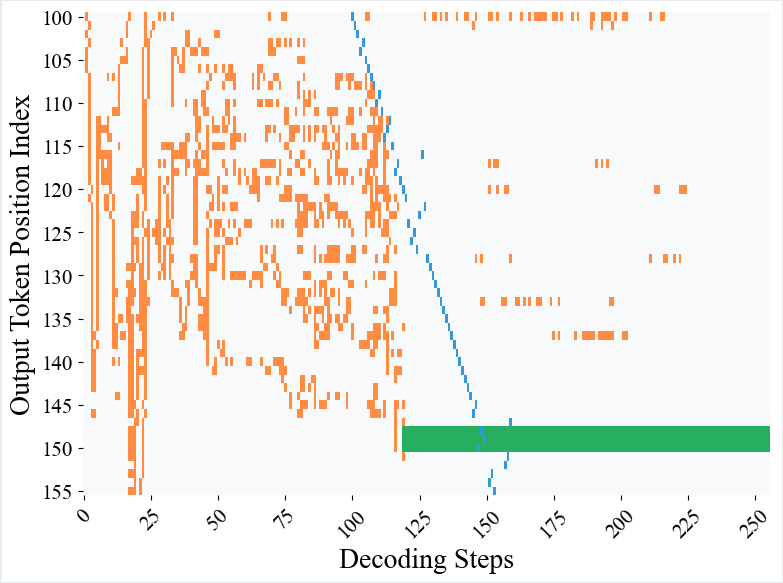

In [44]:
q_i=700
change_matrix, total_changes, change_curves, all_tokens, question_0000_steps_128 = \
analyze_question_position_changes(f'./question_histories_low_conf_none_index_genlen_step256_blocklen32/question_{q_i:04}_steps_256.pt', 
                                  split='test', 
                                  truncated_after_prompt=100, 
                                  truncated_at_end=-100,
                                  save_path=f"figures/paper/position_change_heatmap_low_conf_non_qi_700_step256_blocklen32.pdf")

Analyzing 408 positions over 256 steps
Answer index 300 correct or not: True
gt_token_id_lst [16, 18, 20]
overlay_data torch.Size([256, 408]) all_tokens torch.Size([256, 408])
Heatmap data shape after filtering: torch.Size([56, 256])


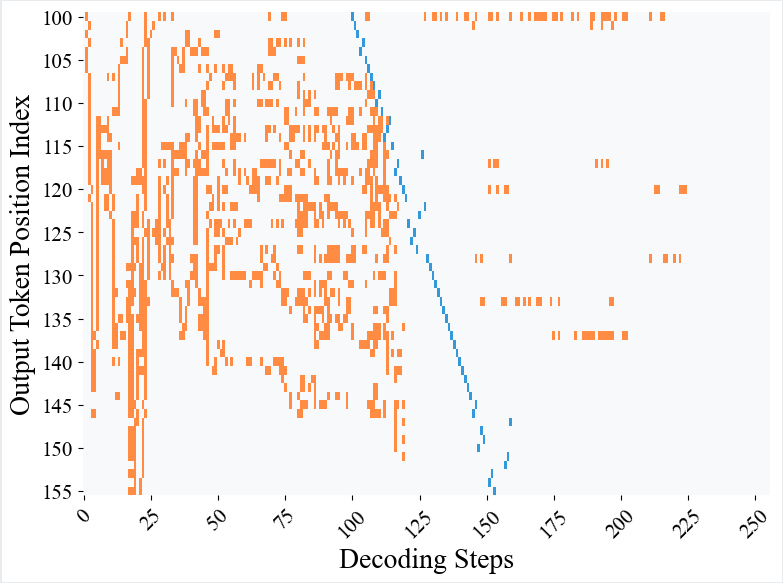

In [51]:
q_i=700
change_matrix, total_changes, change_curves, all_tokens, question_0000_steps_128 = \
analyze_question_position_changes(f'./question_histories_low_conf_none_index_genlen_step256_blocklen32/question_{q_i:04}_steps_256.pt', 
                                  split='test', 
                                  truncated_after_prompt=100, 
                                  truncated_at_end=-100,
                                  save_path=f"figures/paper/position_change_heatmap_low_conf_non_qi_700_step256_blocklen32_box.png")

Analyzing 408 positions over 256 steps
Answer index 375 correct or not: True
gt_token_id_lst [16, 18, 20]
overlay_data torch.Size([256, 408]) all_tokens torch.Size([256, 408])
Heatmap data shape after filtering: torch.Size([56, 256])


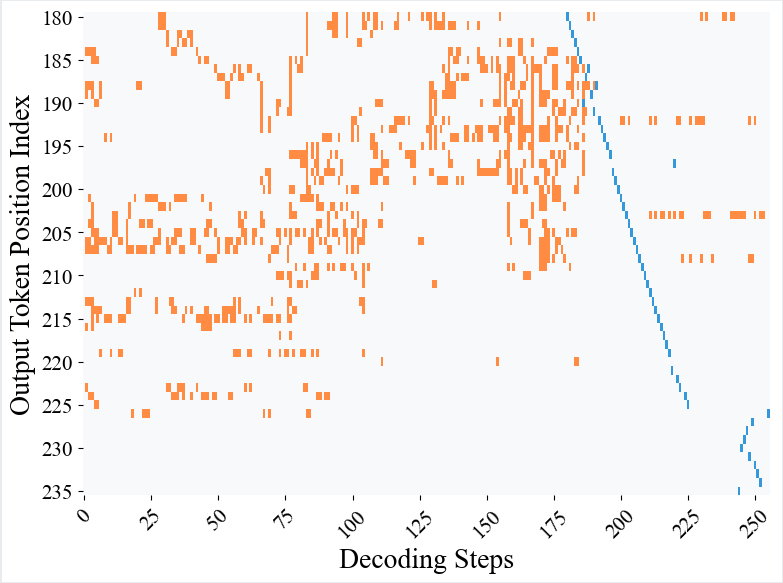

In [52]:
q_i=700
change_matrix, total_changes, change_curves, all_tokens, question_0000_steps_128 = \
analyze_question_position_changes(f'./question_histories_low_conf_constraint_index_genlen_step256_blocklen32/question_{q_i:04}_steps_256.pt', 
                                  split='test', 
                                  truncated_after_prompt=180, 
                                  truncated_at_end=-20,
                                  save_path=f"figures/paper/position_change_heatmap_low_conf_constraint_qi_700_step256_blocklen32_box.png")

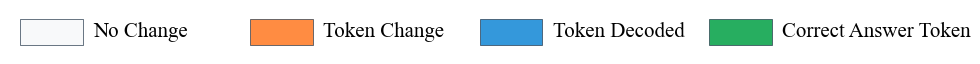

Legend saved as 'color_legend.png' and 'color_legend.pdf'


In [273]:
def create_color_legend():
    """
    Create a compact inline color legend similar to the reference image.
    """
    import matplotlib.pyplot as plt
    import matplotlib.patches as patches
    
    # Define colors and labels
    colors = ['#f8f9fa',    # 0: No change - light gray
          '#ff8c42',    # 1: Normal token change - warm orange
          '#3498db',    # 2: Token decoded - blue
          '#27ae60']    # 3: Change to correct answer - green
    labels = ['No Change', 'Token Change', 'Token Decoded', 'Correct Answer Token']
    
    # Create compact figure
    fig, ax = plt.subplots(figsize=(10, 0.8))
    
    # Parameters for inline layout
    box_width = 0.6
    box_height = 0.3
    text_offset = 0.7
    spacing = 2.2
    
    for i, (color, label) in enumerate(zip(colors, labels)):
        x_pos = i * spacing
        
        # Create colored rectangle with pattern/texture effect
        rect = patches.Rectangle((x_pos, 0.1), box_width, box_height, 
                               facecolor=color, edgecolor='#2c3e50', linewidth=0.5)
        ax.add_patch(rect)
        
        # Add text label to the right of each box
        ax.text(x_pos + text_offset, 0.25, label, 
               ha='left', va='center', fontsize=15)
    
    # Style the plot
    ax.set_xlim(-0.1, len(colors) * spacing - 1)
    ax.set_ylim(0, 0.5)
    
    # Remove all axes elements
    ax.set_xticks([])
    ax.set_yticks([])
    ax.axis('off')
    
    plt.tight_layout()
    
    # Save as high-quality image
    
    # Also save as PDF for vector format
    plt.savefig('./figures/paper/color_legend.pdf', 
                bbox_inches='tight',
                facecolor='white',
                edgecolor='none',
                format='pdf',
                pad_inches=0.1,
                dpi=300)
    
    plt.show()
    
    return fig

# Call the function to create and save the legend
legend_fig = create_color_legend()
print("Legend saved as 'color_legend.png' and 'color_legend.pdf'")